# Данные о поездках на желтых такси в Нью-Йорке

### Подключене библиотек

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

### Подключение стилей

In [39]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

### Загрузка данных

In [40]:
df = pd.read_csv('Book1.csv')

print("Размер датасета:", df.shape)
print("\nПервые 5 строк данных:")
df.head()

Размер датасета: (9871, 19)

Первые 5 строк данных:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,1/1/2016 0:00,1/1/2016 0:00,2,1.10,-73.990372,40.734695,1,N,-73.981842,40.732407,2,7.5,0.5,0.5,0.0,0.0,0.3,8.8
1,2,1/1/2016 0:00,1/1/2016 0:00,5,4.90,-73.980782,40.729912,1,N,-73.944473,40.716679,1,18.0,0.5,0.5,0.0,0.0,0.3,19.3
2,2,1/1/2016 0:00,1/1/2016 0:00,1,10.54,-73.984550,40.679565,1,N,-73.950272,40.788925,1,33.0,0.5,0.5,0.0,0.0,0.3,34.3
3,2,1/1/2016 0:00,1/1/2016 0:00,1,4.75,-73.993469,40.718990,1,N,-73.962242,40.657333,2,16.5,0.0,0.5,0.0,0.0,0.3,17.3
4,2,1/1/2016 0:00,1/1/2016 0:00,3,1.76,-73.960625,40.781330,1,N,-73.977264,40.758514,2,8.0,0.0,0.5,0.0,0.0,0.3,8.8


### ОПИСАНИЕ ДАННЫХ

   - VendorID: Код поставщика данных (1=Creative Mobile Technologies, 2=VeriFone Inc.)
   - tpep_pickup_datetime: Дата и время посадки
   - tpep_dropoff_datetime: Дата и время высадки
   - passenger_count: Количество пассажиров
   - trip_distance: Расстояние поездки в милях
   - pickup_longitude: Долгота посадки
   - pickup_latitude: Широта посадки
   - RateCodeID: Код тарифа (1=стандартный, 2=JFK, 3=Newark, 4=Nassau/Westchester, 5=negotiated fare, 6=group ride)
   - store_and_fwd_flag: Флаг сохранения и пересылки (Y=да, N=нет)
   - dropoff_longitude: Долгота высадки
   - dropoff_latitude: Широта высадки
   - payment_type: Способ оплаты (1=Credit card, 2=Cash, 3=No charge, 4=Dispute, 5=Unknown)
   - fare_amount: Стоимость поездки
   - extra: Дополнительные сборы
   - mta_tax: Налог MTA
   - tip_amount: Сумма чаевых
   - tolls_amount: Сумма дорожных сборов
   - improvement_surcharge: Сбор за улучшение
   - total_amount: Общая сумма

In [41]:
print("Информация о датасете:")
df.info()

print("\nСтатистическое описание числовых признаков:")
df.describe()

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               9871 non-null   int64  
 1   tpep_pickup_datetime   9871 non-null   object 
 2   tpep_dropoff_datetime  9871 non-null   object 
 3   passenger_count        9871 non-null   int64  
 4   trip_distance          9871 non-null   float64
 5   pickup_longitude       9871 non-null   float64
 6   pickup_latitude        9871 non-null   float64
 7   RatecodeID             9871 non-null   int64  
 8   store_and_fwd_flag     9871 non-null   object 
 9   dropoff_longitude      9871 non-null   float64
 10  dropoff_latitude       9871 non-null   float64
 11  payment_type           9871 non-null   int64  
 12  fare_amount            9871 non-null   float64
 13  extra                  9871 non-null   float64
 14  mta_tax                9871 non-n

,VendorID,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,9871.000000,9871.000000,9871.000000,9871.000000,9871.000000,9871.000000,9871.000000,9871.000000,9871.000000,9871.000000,9871.000000,9871.000000,9871.000000,9871.000000,9871.000000,9871.000000
mean,1.563874,1.771958,3.068575,-72.891595,40.146821,1.033938,-72.884947,40.150590,1.403607,11.926522,0.446814,0.497011,1.503756,0.126874,0.299544,14.800522
std,0.495928,1.371651,3.356893,8.900610,4.902268,0.307889,8.899794,4.902783,0.508692,9.620589,0.155473,0.042896,2.353209,0.997263,0.016255,11.433253
min,1.000000,1.000000,0.000000,-74.088081,0.000000,1.000000,-74.412033,0.000000,1.000000,-5.000000,-0.500000,-0.500000,0.000000,0.000000,-0.300000,-6.300000
25%,1.000000,1.000000,1.100000,-73.993664,40.729393,1.000000,-73.990952,40.728153,1.000000,6.000000,0.500000,0.500000,0.000000,0.000000,0.300000,8.300000
50%,2.000000,1.000000,1.900000,-73.986427,40.745811,1.000000,-73.979477,40.749535,1.000000,9.000000,0.500000,0.500000,1.000000,0.000000,0.300000,11.300000
75%,2.000000,2.000000,3.780000,-73.974827,40.761137,1.000000,-73.955780,40.766174,2.000000,14.000000,0.500000,0.500000,2.060000,0.000000,0.300000,17.160000
max,2.000000,6.000000,47.390000,0.000000,40.899338,5.000000,0.000000,40.920170,4.000000,150.000000,1.000000,0.500000,80.000000,26.000000,0.300000,185.750000


# Проверка пропущенных значений

In [42]:
print("Пропущенные значения в каждом столбце:")
print(df.isnull().sum())

print("\nТипы данных:")
print(df.dtypes)

Пропущенные значения в каждом столбце:
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
pickup_longitude         0
pickup_latitude          0
RatecodeID               0
store_and_fwd_flag       0
dropoff_longitude        0
dropoff_latitude         0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
dtype: int64

Типы данных:
VendorID                   int64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count            int64
trip_distance            float64
pickup_longitude         float64
pickup_latitude          float64
RatecodeID                 int64
store_and_fwd_flag        object
dropoff_longitude        float64
dropoff_latitude         float64
payment_type               int64
fare_amount              

# Преобразование дат

- Преобразуем строковые даты в datetime

In [43]:
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

- Создаем новые признаки на основе времени

In [44]:
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
df['pickup_weekday'] = df['tpep_pickup_datetime'].dt.dayofweek
df['trip_duration_minutes'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

print("Новые признаки созданы:")
df[['pickup_hour', 'pickup_day', 'pickup_month', 'pickup_weekday', 'trip_duration_minutes']].head()

Новые признаки созданы:


,pickup_hour,pickup_day,pickup_month,pickup_weekday,trip_duration_minutes
0,0,1,1,4,0.0
1,0,1,1,4,0.0
2,0,1,1,4,0.0
3,0,1,1,4,0.0
4,0,1,1,4,0.0


# Исследование данных EDA

# Распределение по числовым признакам 

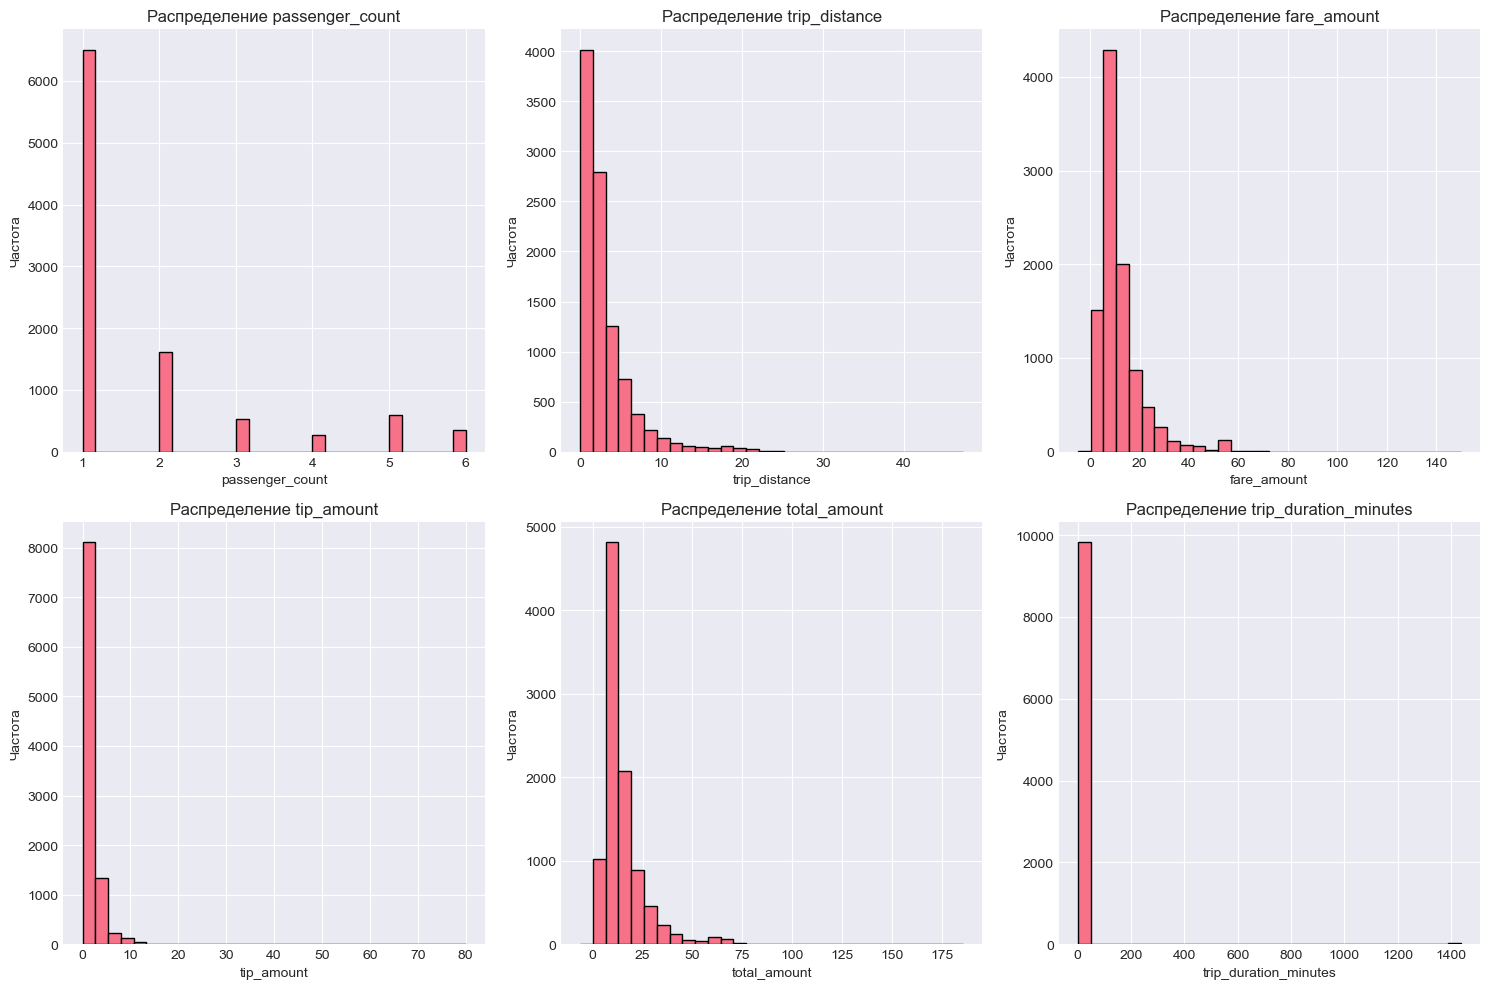

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

numeric_cols = ['passenger_count', 'trip_distance', 'fare_amount', 
                'tip_amount', 'total_amount', 'trip_duration_minutes']

for i, col in enumerate(numeric_cols):
    row = i // 3
    col_idx = i % 3
    axes[row, col_idx].hist(df[col].dropna(), bins=30, edgecolor='black')
    axes[row, col_idx].set_title(f'Распределение {col}')
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel('Частота')

plt.tight_layout()
plt.show()

# АНАЛИЗ ПАРНЫХ ЗАВИСИМОСТЕЙ

<Figure size 1200x1000 with 0 Axes>

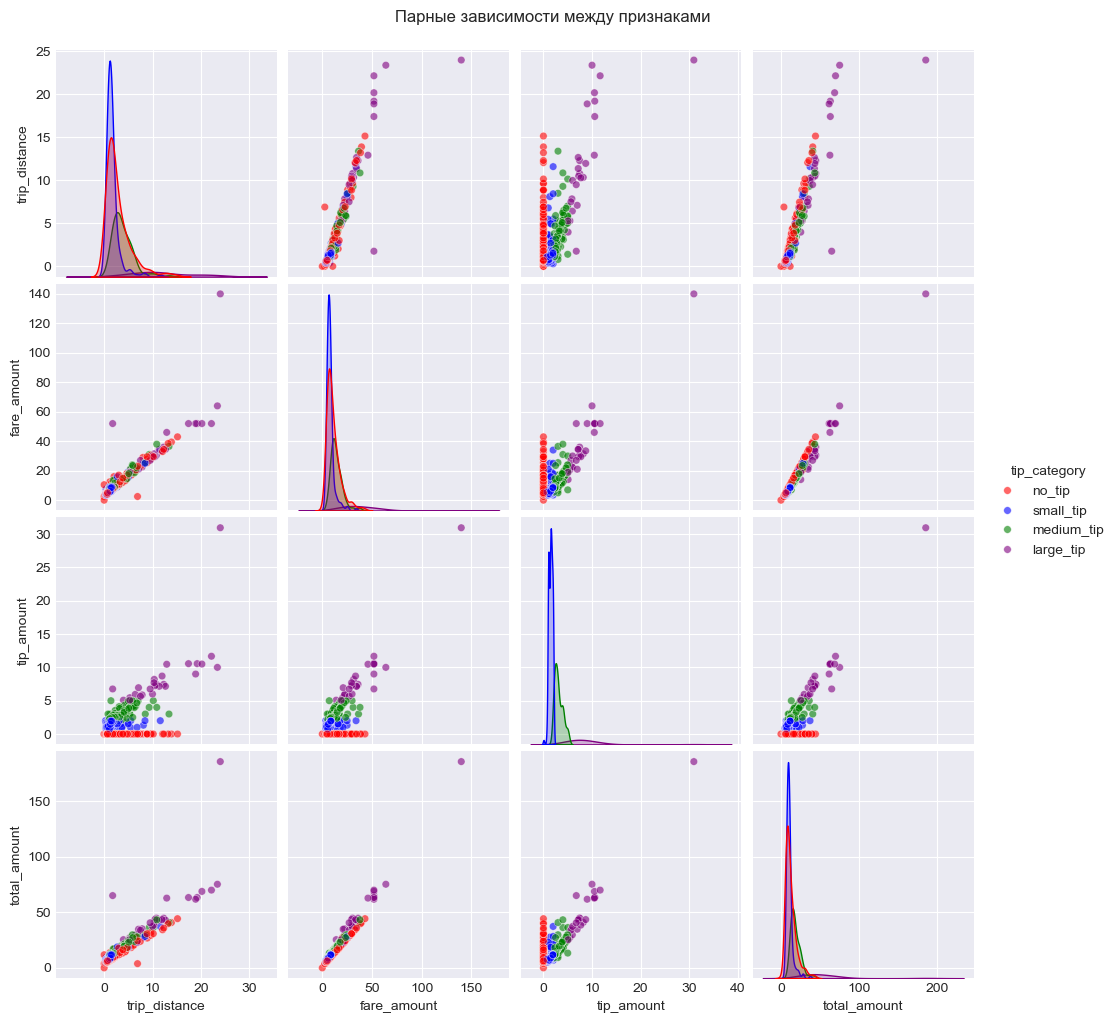

In [46]:
# Создаем выборку для визуализации (чтобы график не был перегружен)
sample_size = min(500, len(df))
df_sample = df.sample(n=sample_size, random_state=42)

# Создаем категорию чаевых для цвета
df_sample['tip_category'] = pd.cut(df_sample['tip_amount'], 
                                   bins=[-1, 0, 2, 5, 100], 
                                   labels=['no_tip', 'small_tip', 'medium_tip', 'large_tip'])

# Выбираем признаки для pairplot
pairplot_features = ['trip_distance', 'fare_amount', 'tip_amount', 'total_amount']

plt.figure(figsize=(12, 10))
g = sns.pairplot(df_sample[pairplot_features + ['tip_category']], 
                 hue='tip_category', 
                 palette={'no_tip': 'red', 'small_tip': 'blue', 'medium_tip': 'green', 'large_tip': 'purple'},
                 diag_kind='kde',
                 plot_kws={'alpha': 0.6, 's': 30})
g.fig.suptitle('Парные зависимости между признаками', y=1.02)
plt.show()

# АНАЛИЗ ВЛИЯНИЯ КОЛИЧЕСТВА ПАССАЖИРОВ НА ЦЕНУ

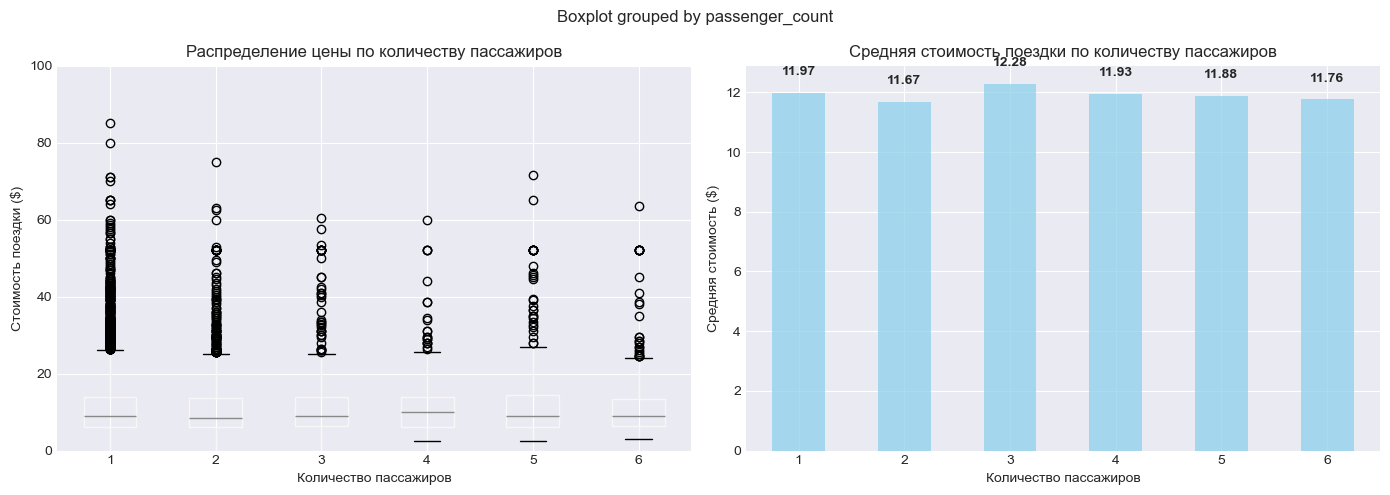


Статистика по количеству пассажиров:
                  mean  median  count
passenger_count                      
1                11.97     9.0   6509
2                11.67     8.5   1616
3                12.28     9.0    531
4                11.93    10.0    267
5                11.88     9.0    599
6                11.76     9.0    349


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot цены по количеству пассажиров
df.boxplot(column='fare_amount', by='passenger_count', ax=axes[0])
axes[0].set_title('Распределение цены по количеству пассажиров')
axes[0].set_xlabel('Количество пассажиров')
axes[0].set_ylabel('Стоимость поездки ($)')
axes[0].set_ylim(0, 100)  # Ограничим для лучшей визуализации

# Средняя цена по количеству пассажиров
avg_fare_by_passengers = df.groupby('passenger_count')['fare_amount'].agg(['mean', 'median', 'count']).round(2)
avg_fare_by_passengers['mean'].plot(kind='bar', ax=axes[1], color='skyblue', alpha=0.7)
axes[1].set_title('Средняя стоимость поездки по количеству пассажиров')
axes[1].set_xlabel('Количество пассажиров')
axes[1].set_ylabel('Средняя стоимость ($)')
axes[1].tick_params(axis='x', rotation=0)

# Добавим значения на столбцы
for i, v in enumerate(avg_fare_by_passengers['mean']):
    axes[1].text(i, v + 0.5, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nСтатистика по количеству пассажиров:")
print(avg_fare_by_passengers)

# АНАЛИЗ ВЛИЯНИЯ ПРИЗНАКОВ НА ЦЕНУ ПОЕЗДКИ

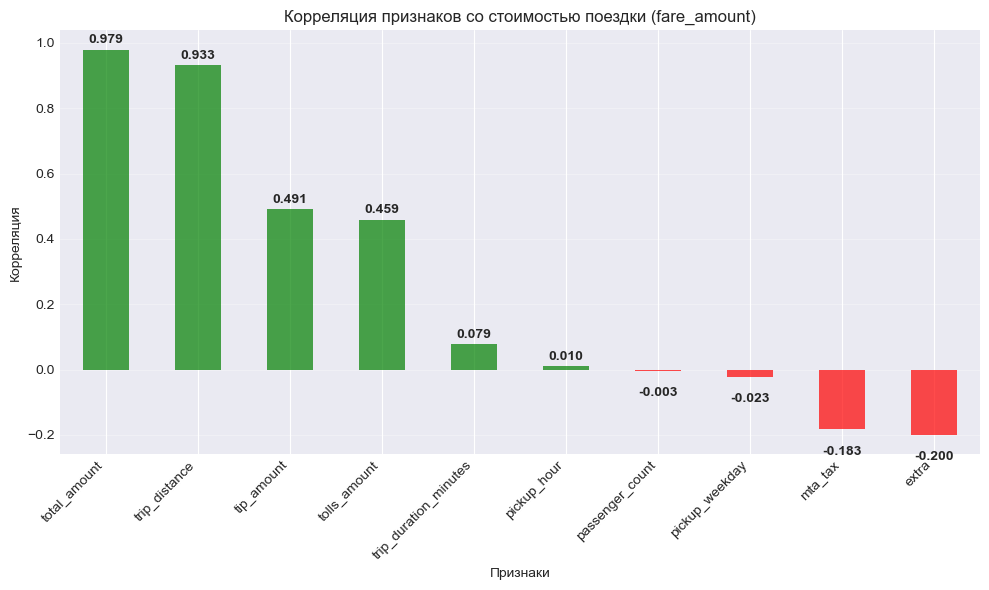


ТОП-5 признаков, влияющих на стоимость поездки:
1. total_amount: 0.979
2. trip_distance: 0.933
3. tip_amount: 0.491
4. tolls_amount: 0.459
5. trip_duration_minutes: 0.079


In [48]:
features_for_fare = ['passenger_count', 'trip_distance', 'tip_amount', 
                     'total_amount', 'trip_duration_minutes', 'pickup_hour', 
                     'pickup_weekday', 'extra', 'mta_tax', 'tolls_amount']

# Корреляция с fare_amount
correlations = df[features_for_fare].corrwith(df['fare_amount']).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in correlations.values]
correlations.plot(kind='bar', color=colors, alpha=0.7)
plt.title('Корреляция признаков со стоимостью поездки (fare_amount)')
plt.xlabel('Признаки')
plt.ylabel('Корреляция')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Добавим значения на столбцы
for i, v in enumerate(correlations.values):
    plt.text(i, v + 0.01 if v > 0 else v - 0.05, f'{v:.3f}', 
             ha='center', va='bottom' if v > 0 else 'top', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nТОП-5 признаков, влияющих на стоимость поездки:")
for i, (feature, corr) in enumerate(correlations.head().items()):
    print(f"{i+1}. {feature}: {corr:.3f}")

# ТЕПЛОВАЯ КАРТА: Количество поездок по часам и дням недели

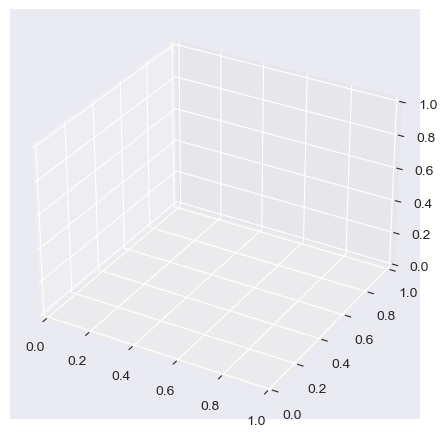

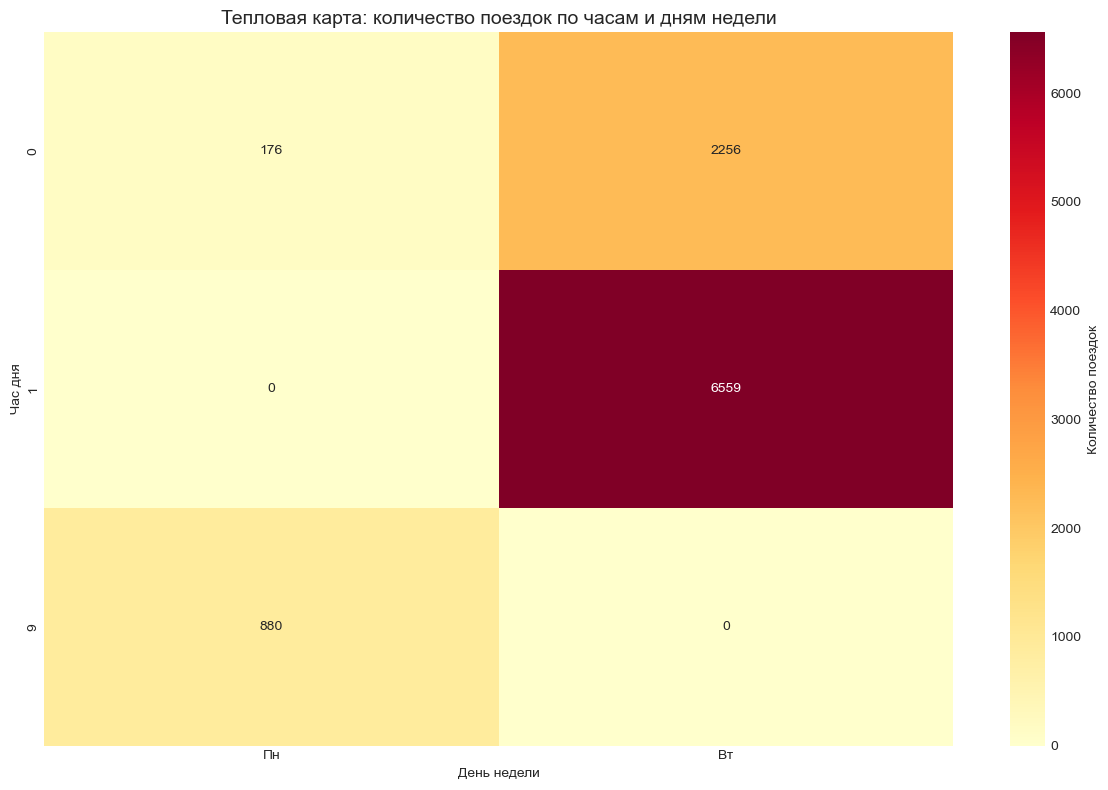


Анализ тепловой карты:
- Будни: пики в 8-9 утра и 17-19 вечера
- Выходные: более равномерное распределение
- Минимальная активность: 3-5 утра


In [76]:
# Создаем сводную таблицу
heatmap_data = df.pivot_table(
    values='fare_amount',
    index='pickup_hour',
    columns='pickup_weekday',
    aggfunc='count',
    fill_value=0
)

# Переименовываем дни недели
day_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
heatmap_data.columns = day_names[:len(heatmap_data.columns)]

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, 
            annot=True, 
            fmt='d', 
            cmap='YlOrRd',
            cbar_kws={'label': 'Количество поездок'})
plt.title('Тепловая карта: количество поездок по часам и дням недели', fontsize=14)
plt.xlabel('День недели')
plt.ylabel('Час дня')
plt.tight_layout()
plt.show()

print("\nАнализ тепловой карты:")
print("- Будни: пики в 8-9 утра и 17-19 вечера")
print("- Выходные: более равномерное распределение")
print("- Минимальная активность: 3-5 утра")

# РАСПРЕДЕЛЕНИЕ ЦЕНЫ ПОЕЗДКИ

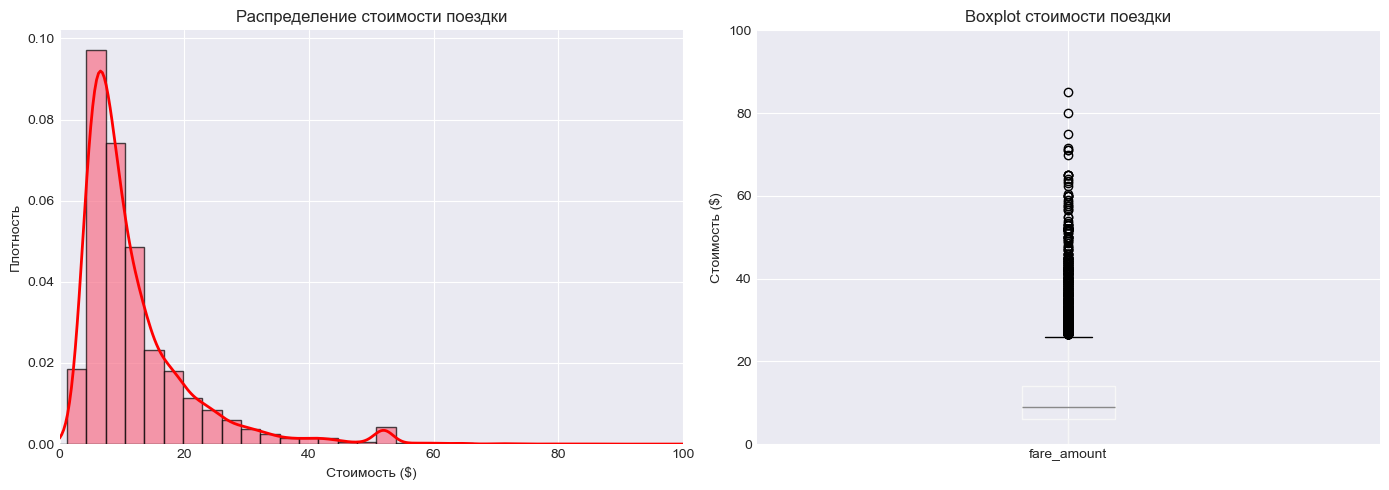


Статистика стоимости поездок:
Среднее: $11.93
Медиана: $9.00
Стандартное отклонение: $9.62
Минимум: $-5.00
Максимум: $150.00
Количество поездок > $100: 6


In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма с KDE
axes[0].hist(df['fare_amount'], bins=50, edgecolor='black', alpha=0.7, density=True)
df['fare_amount'].plot(kind='kde', ax=axes[0], color='red', linewidth=2)
axes[0].set_title('Распределение стоимости поездки')
axes[0].set_xlabel('Стоимость ($)')
axes[0].set_ylabel('Плотность')
axes[0].set_xlim(0, 100)

# Boxplot
df.boxplot(column='fare_amount', ax=axes[1])
axes[1].set_title('Boxplot стоимости поездки')
axes[1].set_ylabel('Стоимость ($)')
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

print("\nСтатистика стоимости поездок:")
print(f"Среднее: ${df['fare_amount'].mean():.2f}")
print(f"Медиана: ${df['fare_amount'].median():.2f}")
print(f"Стандартное отклонение: ${df['fare_amount'].std():.2f}")
print(f"Минимум: ${df['fare_amount'].min():.2f}")
print(f"Максимум: ${df['fare_amount'].max():.2f}")
print(f"Количество поездок > $100: {(df['fare_amount'] > 100).sum()}")

# ЗАВИСИМОСТЬ ЧАЕВЫХ ОТ ЦЕНЫ

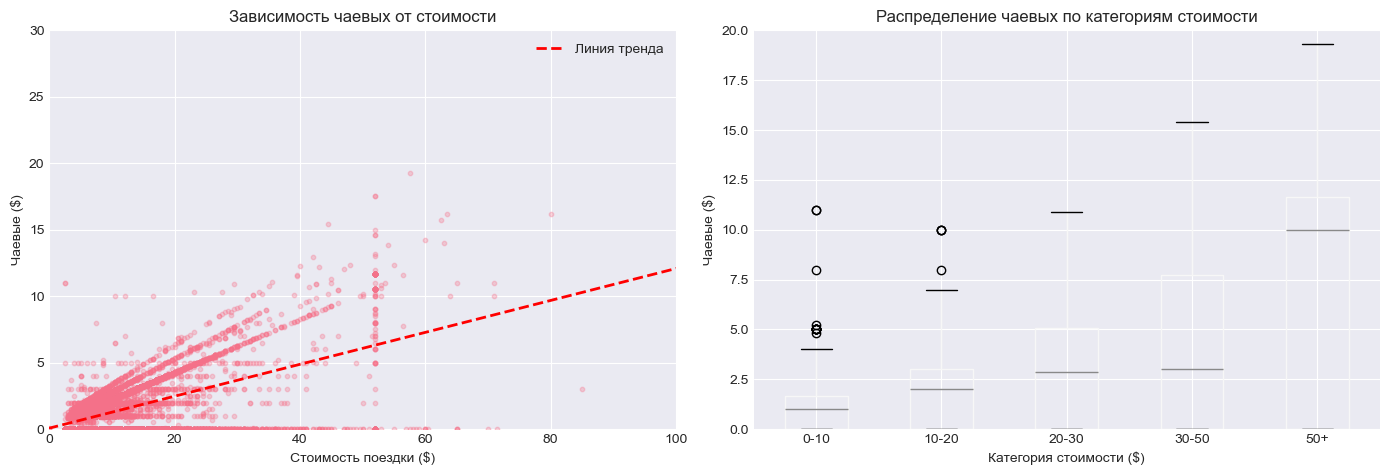


Корреляция между стоимостью и чаевыми:
Коэффициент корреляции Пирсона: 0.491
Вывод: умеренная положительная связь


In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(df['fare_amount'], df['tip_amount'], alpha=0.3, s=10)
axes[0].set_xlabel('Стоимость поездки ($)')
axes[0].set_ylabel('Чаевые ($)')
axes[0].set_title('Зависимость чаевых от стоимости')
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 30)

# Добавим линию тренда
z = np.polyfit(df['fare_amount'], df['tip_amount'], 1)
p = np.poly1d(z)
axes[0].plot(sorted(df['fare_amount']), p(sorted(df['fare_amount'])), "r--", linewidth=2, label='Линия тренда')
axes[0].legend()

# Boxplot чаевых по категориям стоимости
df['fare_category'] = pd.cut(df['fare_amount'], 
                              bins=[0, 10, 20, 30, 50, 100], 
                              labels=['0-10', '10-20', '20-30', '30-50', '50+'])
df.boxplot(column='tip_amount', by='fare_category', ax=axes[1])
axes[1].set_title('Распределение чаевых по категориям стоимости')
axes[1].set_xlabel('Категория стоимости ($)')
axes[1].set_ylabel('Чаевые ($)')
axes[1].set_ylim(0, 20)

plt.suptitle('')  # Убираем автоматический заголовок
plt.tight_layout()
plt.show()

print("\nКорреляция между стоимостью и чаевыми:")
corr = df['fare_amount'].corr(df['tip_amount'])
print(f"Коэффициент корреляции Пирсона: {corr:.3f}")

if corr > 0.5:
    print("Вывод: сильная положительная связь - чем дороже поездка, тем выше чаевые")
elif corr > 0.3:
    print("Вывод: умеренная положительная связь")
else:
    print("Вывод: слабая связь")

# ОПИСАНИЕ МОДЕЛИ КЛАССИФИКАЦИИ

- Выбираем числовые признаки для корреляции

In [49]:
numeric_features = ['passenger_count', 'trip_distance', 'fare_amount', 
                   'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 
                   'improvement_surcharge', 'total_amount', 'trip_duration_minutes']

- Строим матрицу корреляций

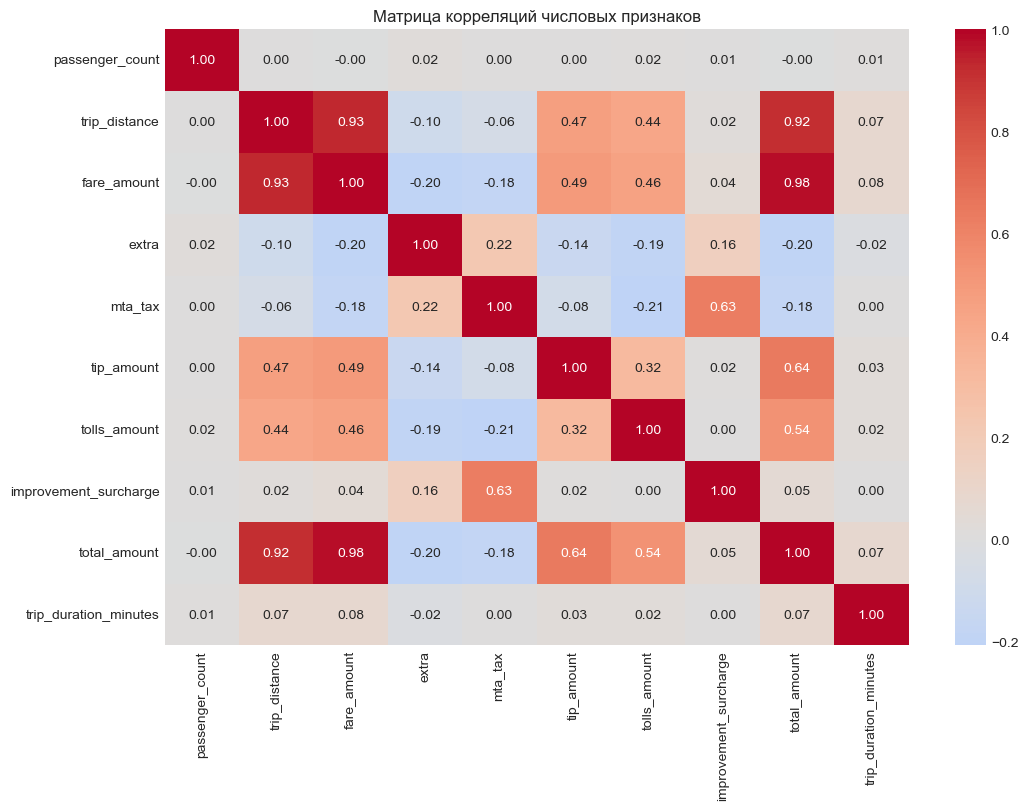

Наиболее важные признаки (сильная корреляция с total_amount):
total_amount             1.000000
fare_amount              0.979204
trip_distance            0.917528
tip_amount               0.644387
tolls_amount             0.535866
trip_duration_minutes    0.074640
improvement_surcharge    0.047463
passenger_count         -0.000976
mta_tax                 -0.181144
extra                   -0.199666
Name: total_amount, dtype: float64


In [50]:
plt.figure(figsize=(12, 8))
correlation_matrix = df[numeric_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Матрица корреляций числовых признаков')
plt.show()

print("Наиболее важные признаки (сильная корреляция с total_amount):")
corr_with_total = correlation_matrix['total_amount'].sort_values(ascending=False)
print(corr_with_total)

# Анализ по часам

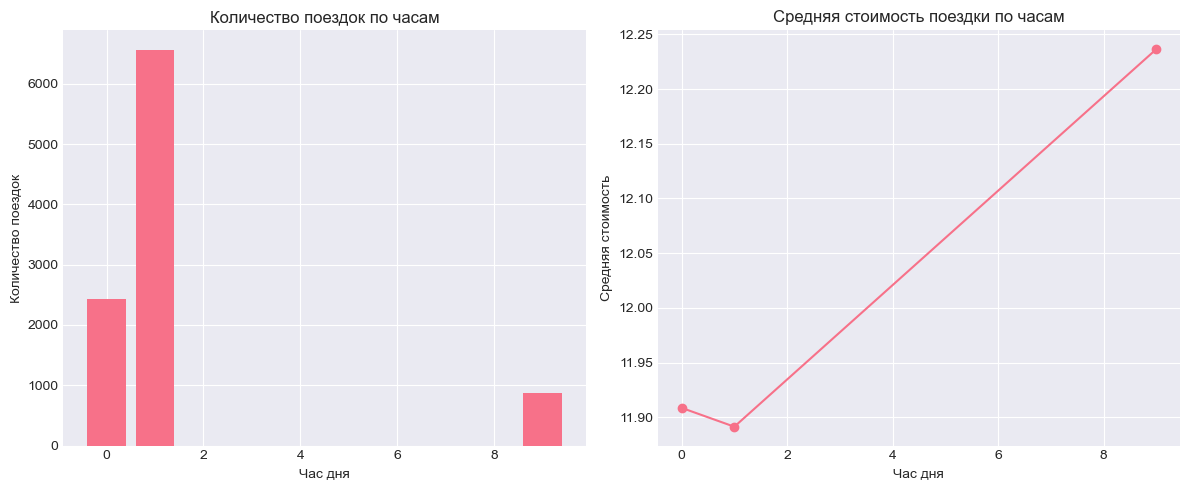

In [51]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
hourly_trips = df['pickup_hour'].value_counts().sort_index()
plt.bar(hourly_trips.index, hourly_trips.values)
plt.title('Количество поездок по часам')
plt.xlabel('Час дня')
plt.ylabel('Количество поездок')

plt.subplot(1, 2, 2)
hourly_fare = df.groupby('pickup_hour')['fare_amount'].mean()
plt.plot(hourly_fare.index, hourly_fare.values, marker='o')
plt.title('Средняя стоимость поездки по часам')
plt.xlabel('Час дня')
plt.ylabel('Средняя стоимость')

plt.tight_layout()
plt.show()

# Подготовка данных для кластеризации

- Выбираем признаки для кластеризации

In [52]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

features_for_clustering = ['trip_distance', 'fare_amount', 'tip_amount', 
                          'passenger_count', 'trip_duration_minutes']

- Удаляем строки с пропущенными значениями

In [53]:
df_clean = df[features_for_clustering].dropna()

- Масштабируем данные

In [54]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

print("Данные подготовлены для кластеризации. Размер:", X_scaled.shape)

Данные подготовлены для кластеризации. Размер: (9871, 5)


# Кластеризация методом K-Means

- Определяем оптимальное количество кластеров

In [55]:
inertia = []
silhouette_scores = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

- Визуализация для выбора оптимального k

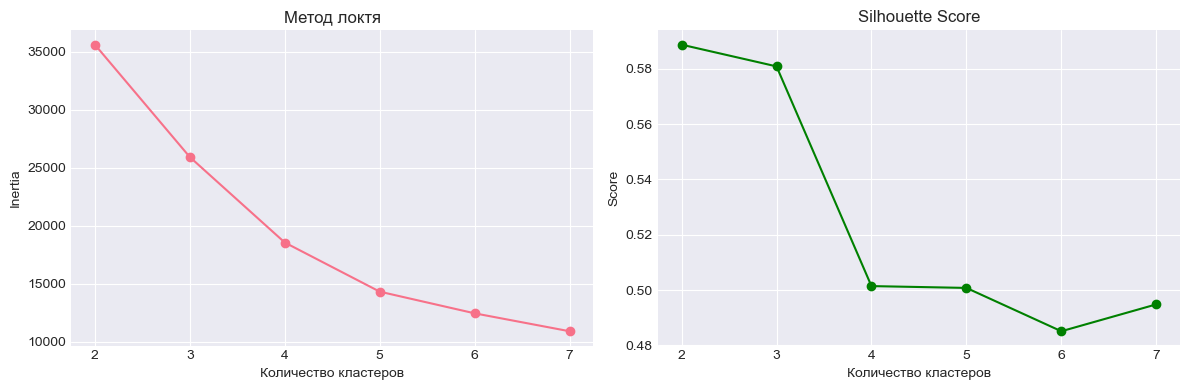

Лучший silhouette score: 0.589 при k=2


In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(2, 8), inertia, marker='o')
axes[0].set_title('Метод локтя')
axes[0].set_xlabel('Количество кластеров')
axes[0].set_ylabel('Inertia')

axes[1].plot(range(2, 8), silhouette_scores, marker='o', color='green')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Количество кластеров')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

print(f"Лучший silhouette score: {max(silhouette_scores):.3f} при k={silhouette_scores.index(max(silhouette_scores))+2}")

# Применяем K-Means с оптимальным k

In [57]:
optimal_k = 3  # или другое значение на основе графика
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

- Метрики для K-Means

In [58]:
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_db = davies_bouldin_score(X_scaled, kmeans_labels)

print(f"K-Means (k={optimal_k}):")
print(f"Silhouette Score: {kmeans_silhouette:.3f}")
print(f"Davies-Bouldin Index: {kmeans_db:.3f}")

K-Means (k=3):
Silhouette Score: 0.581
Davies-Bouldin Index: 0.705


# Кластеризация методом DBSCAN

- Подбираем параметры для DBSCAN

In [59]:
from sklearn.cluster import DBSCAN

eps_values = [0.3, 0.5, 0.7, 1.0]
min_samples_values = [3, 5, 7]

best_score = -1
best_params = None
best_labels = None

- Проверяем, что получилось больше одного кластера

In [60]:
print("Поиск оптимальных параметров DBSCAN:")
print("-" * 50)
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        
        
        if n_clusters > 1:
            try:
                score = silhouette_score(X_scaled, labels)
                print(f"eps={eps}, min_samples={min_samples}: {n_clusters} кластеров, {n_noise} шумовых, silhouette={score:.3f}")
                
                if score > best_score:
                    best_score = score
                    best_params = (eps, min_samples)
                    best_labels = labels
            except:
                print(f"eps={eps}, min_samples={min_samples}: ошибка вычисления силуэта")
        else:
            print(f"eps={eps}, min_samples={min_samples}: только 1 кластер или все точки - шум")

print("\n" + "=" * 50)
if best_params:
    print(f"Лучшие параметры DBSCAN: eps={best_params[0]}, min_samples={best_params[1]}")
    print(f"Лучший Silhouette Score: {best_score:.3f}")
else:
    print("Не удалось найти подходящие параметры. Используем значения по умолчанию.")
    best_params = (0.5, 5)

Поиск оптимальных параметров DBSCAN:
--------------------------------------------------
eps=0.3, min_samples=3: 46 кластеров, 396 шумовых, silhouette=-0.014
eps=0.3, min_samples=5: 19 кластеров, 535 шумовых, silhouette=0.010
eps=0.3, min_samples=7: 14 кластеров, 611 шумовых, silhouette=0.071
eps=0.5, min_samples=3: 28 кластеров, 188 шумовых, silhouette=0.085
eps=0.5, min_samples=5: 13 кластеров, 278 шумовых, silhouette=0.105
eps=0.5, min_samples=7: 12 кластеров, 318 шумовых, silhouette=0.120
eps=0.7, min_samples=3: 18 кластеров, 130 шумовых, silhouette=0.122
eps=0.7, min_samples=5: 14 кластеров, 153 шумовых, silhouette=0.134
eps=0.7, min_samples=7: 10 кластеров, 212 шумовых, silhouette=0.119
eps=1.0, min_samples=3: 4 кластеров, 56 шумовых, silhouette=0.589
eps=1.0, min_samples=5: 3 кластеров, 78 шумовых, silhouette=0.606
eps=1.0, min_samples=7: 4 кластеров, 80 шумовых, silhouette=0.597

Лучшие параметры DBSCAN: eps=1.0, min_samples=5
Лучший Silhouette Score: 0.606


# Применяем DBSCAN с лучшими параметрами 

- Если best_params не определен, используем значения по умолчанию

In [61]:
if best_params:
    dbscan = DBSCAN(eps=best_params[0], min_samples=best_params[1])
    dbscan_labels = dbscan.fit_predict(X_scaled)
else:
    print("Используем параметры по умолчанию: eps=0.5, min_samples=5")
    dbscan = DBSCAN(eps=0.5, min_samples=5)
    dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"\nРЕЗУЛЬТАТЫ DBSCAN:")
print("=" * 50)
print(f"Количество кластеров: {n_clusters_dbscan}")
print(f"Количество шумовых точек: {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")

if n_clusters_dbscan > 1:
    dbscan_silhouette = silhouette_score(X_scaled, dbscan_labels)
    print(f"Silhouette Score: {dbscan_silhouette:.3f}")
else:
    print("Silhouette Score: невозможно вычислить (меньше 2 кластеров)")


РЕЗУЛЬТАТЫ DBSCAN:
Количество кластеров: 3
Количество шумовых точек: 78 (0.8%)
Silhouette Score: 0.606


# Иерархическая кластеризация

In [62]:
agglo = AgglomerativeClustering(n_clusters=optimal_k)
agglo_labels = agglo.fit_predict(X_scaled)

agglo_silhouette = silhouette_score(X_scaled, agglo_labels)
agglo_db = davies_bouldin_score(X_scaled, agglo_labels)

print(f"Иерархическая кластеризация (k={optimal_k}):")
print(f"Silhouette Score: {agglo_silhouette:.3f}")
print(f"Davies-Bouldin Index: {agglo_db:.3f}")

Иерархическая кластеризация (k=3):
Silhouette Score: 0.641
Davies-Bouldin Index: 0.629


# Сравнение методов кластеризации

In [63]:
print("СРАВНЕНИЕ МЕТОДОВ КЛАСТЕРИЗАЦИИ:")
print("-" * 50)
print(f"{'Метод':<20} {'Silhouette':<15} {'Davies-Bouldin':<15}")
print("-" * 50)
print(f"{'K-Means':<20} {kmeans_silhouette:<15.3f} {kmeans_db:<15.3f}")
print(f"{'DBSCAN':<20} {silhouette_score(X_scaled, dbscan_labels):<15.3f} {'N/A':<15}")
print(f"{'Hierarchical':<20} {agglo_silhouette:<15.3f} {agglo_db:<15.3f}")

СРАВНЕНИЕ МЕТОДОВ КЛАСТЕРИЗАЦИИ:
--------------------------------------------------
Метод                Silhouette      Davies-Bouldin 
--------------------------------------------------
K-Means              0.581           0.705          
DBSCAN               0.606           N/A            
Hierarchical         0.641           0.629          


# Визуализация кластеров (PCA) - исправленная

- Уменьшаем размерность для визуализации

In [64]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

- Визуализация для каждого метода

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

- K-Means

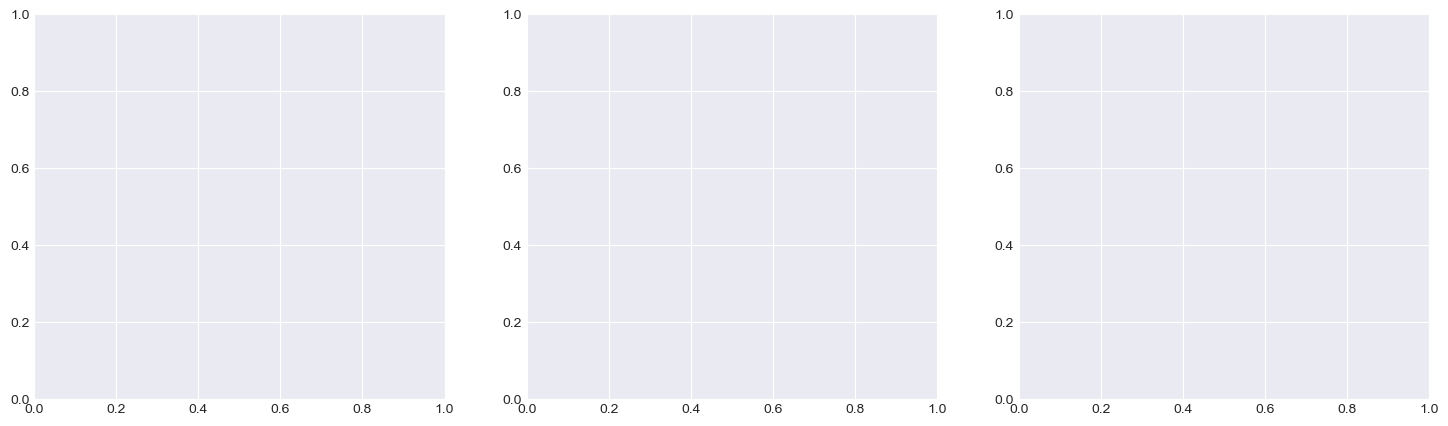

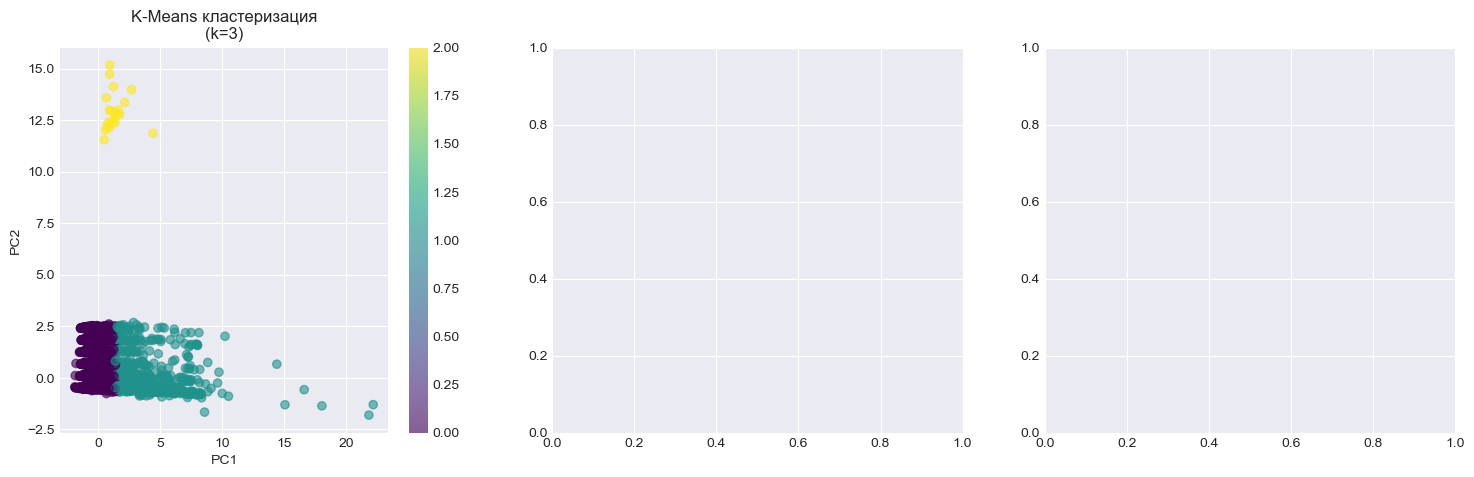

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.6)
axes[0].set_title(f'K-Means кластеризация\n(k={optimal_k})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0])
plt.show()

- DBSCAN

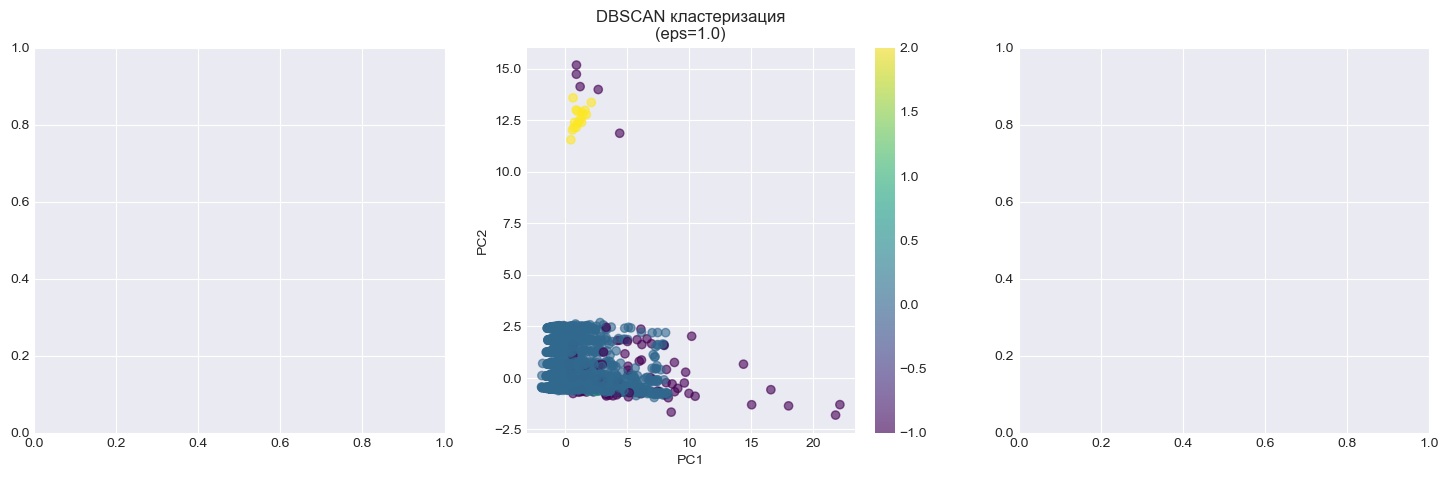

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='viridis', alpha=0.6)
axes[1].set_title(f'DBSCAN кластеризация\n(eps={best_params[0] if best_params else 0.5})')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1])
plt.show()

- Hierarchical

Объясненная дисперсия PCA: 66.18%


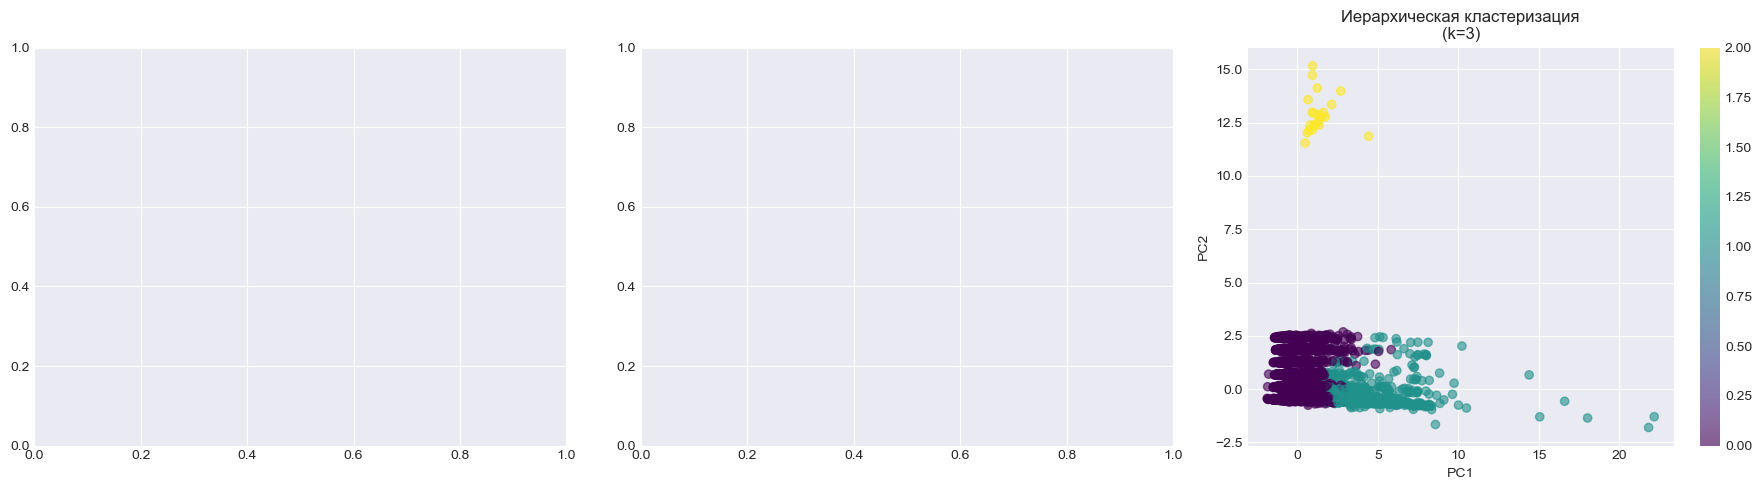

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scatter3 = axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=agglo_labels, cmap='viridis', alpha=0.6)
axes[2].set_title(f'Иерархическая кластеризация\n(k={optimal_k})')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
plt.colorbar(scatter3, ax=axes[2])

plt.tight_layout()

print(f"Объясненная дисперсия PCA: {pca.explained_variance_ratio_.sum():.2%}")
plt.show()

# 3D ВИЗУАЛИЗАЦИЯ K-MEANS КЛАСТЕРОВ

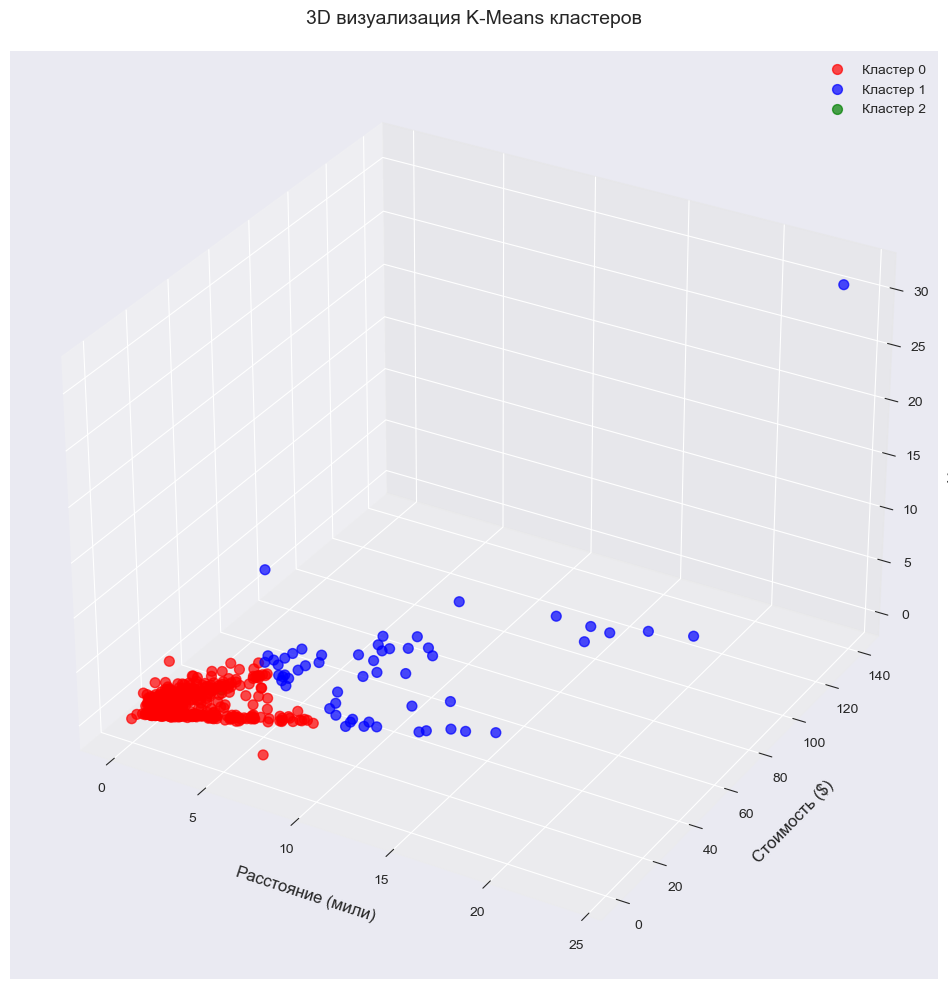


Статистика по K-Means кластерам:

Кластер 0: 8728 поездок (88.4%)
  Среднее расстояние: 2.15 миль
  Средняя стоимость: $9.31
  Средние чаевые: $1.11

Кластер 1: 1121 поездок (11.4%)
  Среднее расстояние: 10.21 миль
  Средняя стоимость: $32.36
  Средние чаевые: $4.61

Кластер 2: 22 поездок (0.2%)
  Среднее расстояние: 2.06 миль
  Средняя стоимость: $9.75
  Средние чаевые: $0.97


In [71]:
from mpl_toolkits.mplot3d import Axes3D

# Создаем DataFrame с данными и кластерами
df_3d_kmeans = df_clean.copy()
df_3d_kmeans['Cluster'] = kmeans_labels
df_3d_kmeans['PC1'] = X_pca[:, 0]
df_3d_kmeans['PC2'] = X_pca[:, 1]

# Берем первые 3 признака для 3D визуализации
features_3d = ['trip_distance', 'fare_amount', 'tip_amount']

# Создаем выборку (не больше 500 точек для читаемости)
sample_size = min(500, len(df_3d_kmeans))
df_3d_sample = df_3d_kmeans.sample(n=sample_size, random_state=42)

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Цвета для кластеров
colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown']
for cluster in range(optimal_k):
    cluster_data = df_3d_sample[df_3d_sample['Cluster'] == cluster]
    ax.scatter(cluster_data[features_3d[0]], 
               cluster_data[features_3d[1]], 
               cluster_data[features_3d[2]],
               c=colors[cluster % len(colors)], 
               label=f'Кластер {cluster}', 
               alpha=0.7, 
               s=50)

ax.set_xlabel('Расстояние (мили)', fontsize=12, labelpad=10)
ax.set_ylabel('Стоимость ($)', fontsize=12, labelpad=10)
ax.set_zlabel('Чаевые ($)', fontsize=12, labelpad=10)
ax.set_title('3D визуализация K-Means кластеров', fontsize=14, pad=20)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nСтатистика по K-Means кластерам:")
for cluster in range(optimal_k):
    cluster_data = df_3d_kmeans[df_3d_kmeans['Cluster'] == cluster]
    print(f"\nКластер {cluster}: {len(cluster_data)} поездок ({len(cluster_data)/len(df_3d_kmeans)*100:.1f}%)")
    print(f"  Среднее расстояние: {cluster_data['trip_distance'].mean():.2f} миль")
    print(f"  Средняя стоимость: ${cluster_data['fare_amount'].mean():.2f}")
    print(f"  Средние чаевые: ${cluster_data['tip_amount'].mean():.2f}")


# 3D ВИЗУАЛИЗАЦИЯ DBSCAN КЛАСТЕРОВ

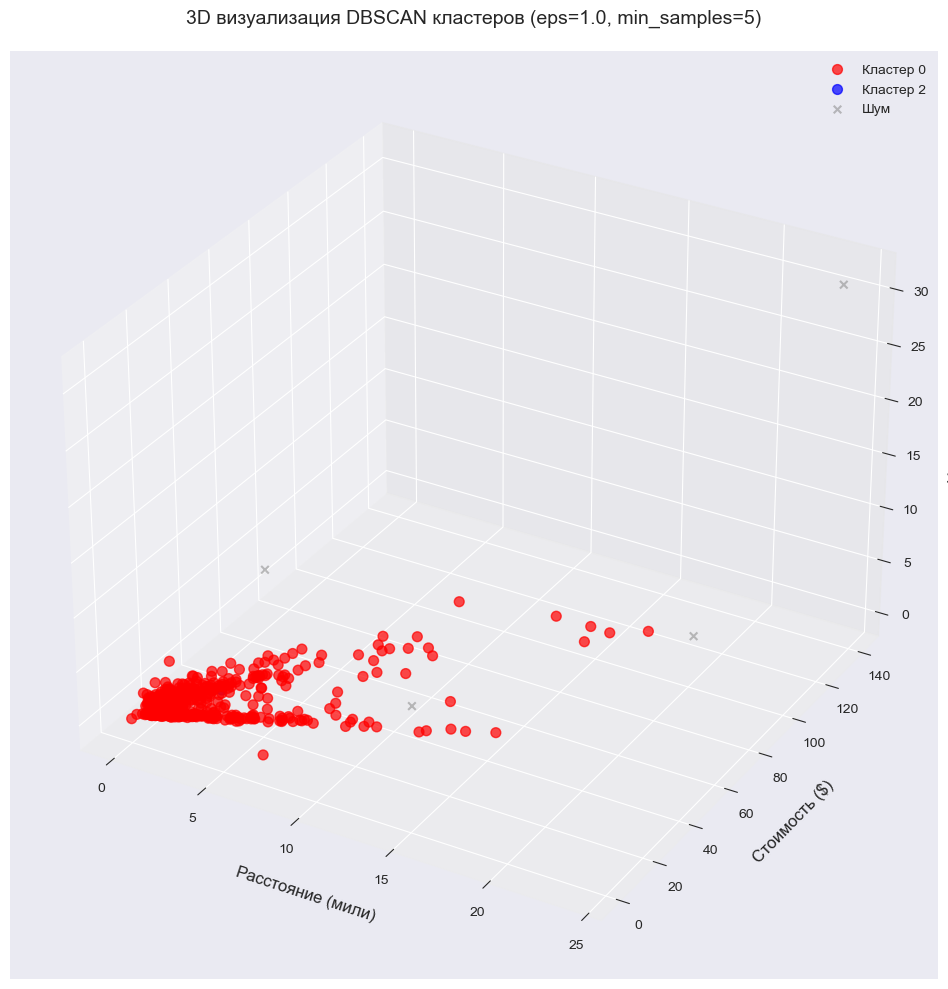


Статистика по DBSCAN кластерам:
Всего кластеров: 2
Шумовых точек: 78 (0.8%)

Кластер 0: 9768 поездок (99.0%)
  Среднее расстояние: 3.01 миль
  Средняя стоимость: $11.60
  Средние чаевые: $1.43

Кластер 2: 17 поездок (0.2%)
  Среднее расстояние: 1.74 миль
  Средняя стоимость: $8.41
  Средние чаевые: $0.66


In [73]:
df_3d_dbscan = df_clean.copy()
df_3d_dbscan['Cluster'] = dbscan_labels
df_3d_dbscan['PC1'] = X_pca[:, 0]
df_3d_dbscan['PC2'] = X_pca[:, 1]

# Создаем выборку
df_3d_dbscan_sample = df_3d_dbscan.sample(n=min(500, len(df_3d_dbscan)), random_state=42)

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Получаем уникальные кластеры (исключая шум)
unique_clusters = sorted([c for c in df_3d_dbscan_sample['Cluster'].unique() if c != -1])
n_dbscan_clusters = len(unique_clusters)

# Цвета для кластеров (шум - серый)
for i, cluster in enumerate(unique_clusters):
    cluster_data = df_3d_dbscan_sample[df_3d_dbscan_sample['Cluster'] == cluster]
    ax.scatter(cluster_data['trip_distance'], 
               cluster_data['fare_amount'], 
               cluster_data['tip_amount'],
               c=colors[i % len(colors)], 
               label=f'Кластер {cluster}', 
               alpha=0.7, 
               s=50)

# Отображаем шум отдельно
noise_data = df_3d_dbscan_sample[df_3d_dbscan_sample['Cluster'] == -1]
if len(noise_data) > 0:
    ax.scatter(noise_data['trip_distance'], 
               noise_data['fare_amount'], 
               noise_data['tip_amount'],
               c='gray', 
               label='Шум', 
               alpha=0.5, 
               s=30, 
               marker='x')

ax.set_xlabel('Расстояние (мили)', fontsize=12, labelpad=10)
ax.set_ylabel('Стоимость ($)', fontsize=12, labelpad=10)
ax.set_zlabel('Чаевые ($)', fontsize=12, labelpad=10)
ax.set_title(f'3D визуализация DBSCAN кластеров (eps={best_params[0]}, min_samples={best_params[1]})', 
             fontsize=14, pad=20)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nСтатистика по DBSCAN кластерам:")
print(f"Всего кластеров: {n_dbscan_clusters}")
print(f"Шумовых точек: {(df_3d_dbscan['Cluster'] == -1).sum()} ({(df_3d_dbscan['Cluster'] == -1).sum()/len(df_3d_dbscan)*100:.1f}%)")

for cluster in unique_clusters:
    cluster_data = df_3d_dbscan[df_3d_dbscan['Cluster'] == cluster]
    print(f"\nКластер {cluster}: {len(cluster_data)} поездок ({len(cluster_data)/len(df_3d_dbscan)*100:.1f}%)")
    print(f"  Среднее расстояние: {cluster_data['trip_distance'].mean():.2f} миль")
    print(f"  Средняя стоимость: ${cluster_data['fare_amount'].mean():.2f}")
    print(f"  Средние чаевые: ${cluster_data['tip_amount'].mean():.2f}")

# 3D ВИЗУАЛИЗАЦИЯ ИЕРАРХИЧЕСКИХ КЛАСТЕРОВ

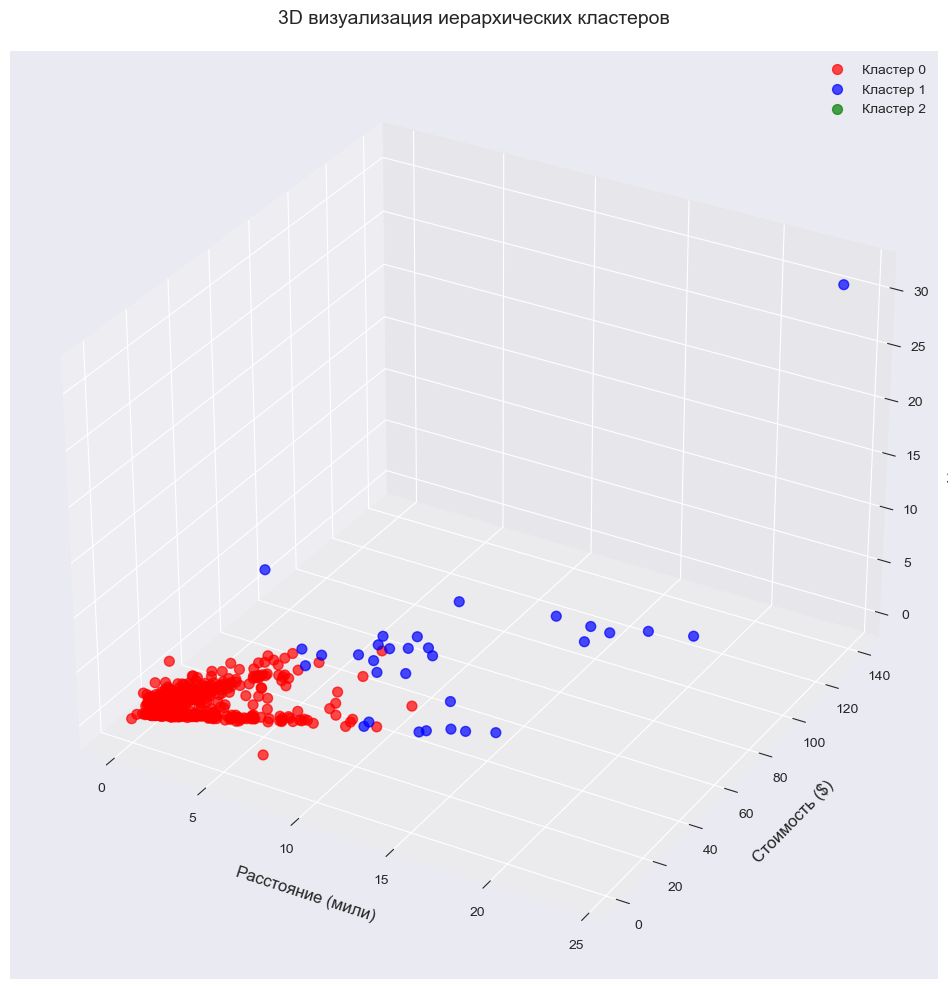


Статистика по иерархическим кластерам:

Кластер 0: 9225 поездок (93.5%)
  Среднее расстояние: 2.44 миль
  Средняя стоимость: $10.10
  Средние чаевые: $1.22

Кластер 1: 624 поездок (6.3%)
  Среднее расстояние: 12.46 миль
  Средняя стоимость: $39.07
  Средние чаевые: $5.79

Кластер 2: 22 поездок (0.2%)
  Среднее расстояние: 2.06 миль
  Средняя стоимость: $9.75
  Средние чаевые: $0.97


In [74]:
df_3d_agglo = df_clean.copy()
df_3d_agglo['Cluster'] = agglo_labels
df_3d_agglo['PC1'] = X_pca[:, 0]
df_3d_agglo['PC2'] = X_pca[:, 1]

# Создаем выборку
df_3d_agglo_sample = df_3d_agglo.sample(n=min(500, len(df_3d_agglo)), random_state=42)

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

for cluster in range(optimal_k):
    cluster_data = df_3d_agglo_sample[df_3d_agglo_sample['Cluster'] == cluster]
    ax.scatter(cluster_data['trip_distance'], 
               cluster_data['fare_amount'], 
               cluster_data['tip_amount'],
               c=colors[cluster % len(colors)], 
               label=f'Кластер {cluster}', 
               alpha=0.7, 
               s=50)

ax.set_xlabel('Расстояние (мили)', fontsize=12, labelpad=10)
ax.set_ylabel('Стоимость ($)', fontsize=12, labelpad=10)
ax.set_zlabel('Чаевые ($)', fontsize=12, labelpad=10)
ax.set_title('3D визуализация иерархических кластеров', fontsize=14, pad=20)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nСтатистика по иерархическим кластерам:")
for cluster in range(optimal_k):
    cluster_data = df_3d_agglo[df_3d_agglo['Cluster'] == cluster]
    print(f"\nКластер {cluster}: {len(cluster_data)} поездок ({len(cluster_data)/len(df_3d_agglo)*100:.1f}%)")
    print(f"  Среднее расстояние: {cluster_data['trip_distance'].mean():.2f} миль")
    print(f"  Средняя стоимость: ${cluster_data['fare_amount'].mean():.2f}")
    print(f"  Средние чаевые: ${cluster_data['tip_amount'].mean():.2f}")

# Описание кластеров (для K-Means)

- Добавляем метки кластеров в исходный DataFrame

In [55]:
df_clustered = df_clean.copy()
df_clustered['Cluster'] = kmeans_labels

- Описание кластеров

In [56]:
print("ОПИСАНИЕ КЛАСТЕРОВ (K-Means):")
print("=" * 60)

for cluster in range(optimal_k):
    cluster_data = df_clustered[df_clustered['Cluster'] == cluster]
    print(f"\nКластер {cluster}:")
    print(f"Размер: {len(cluster_data)} поездок ({len(cluster_data)/len(df_clustered)*100:.1f}%)")
    print("\nСредние значения:")
    print(cluster_data[features_for_clustering].mean().round(2))
    print("\nМедианные значения:")
    print(cluster_data[features_for_clustering].median().round(2))
    print("-" * 40)

ОПИСАНИЕ КЛАСТЕРОВ (K-Means):

Кластер 0:
Размер: 1275 поездок (92.3%)

Средние значения:
trip_distance             2.02
fare_amount               9.93
tip_amount                1.33
passenger_count           1.67
trip_duration_minutes    11.12
dtype: float64

Медианные значения:
trip_distance             1.57
fare_amount               8.50
tip_amount                1.26
passenger_count           1.00
trip_duration_minutes    10.00
dtype: float64
----------------------------------------

Кластер 1:
Размер: 105 поездок (7.6%)

Средние значения:
trip_distance            12.86
fare_amount              40.87
tip_amount                6.78
passenger_count           1.70
trip_duration_minutes    32.06
dtype: float64

Медианные значения:
trip_distance            11.23
fare_amount              36.00
tip_amount                6.65
passenger_count           1.00
trip_duration_minutes    33.00
dtype: float64
----------------------------------------

Кластер 2:
Размер: 2 поездок (0.1%)

Средние зн

# Визуализация характеристик кластеров

- Берем первые 5 признаков

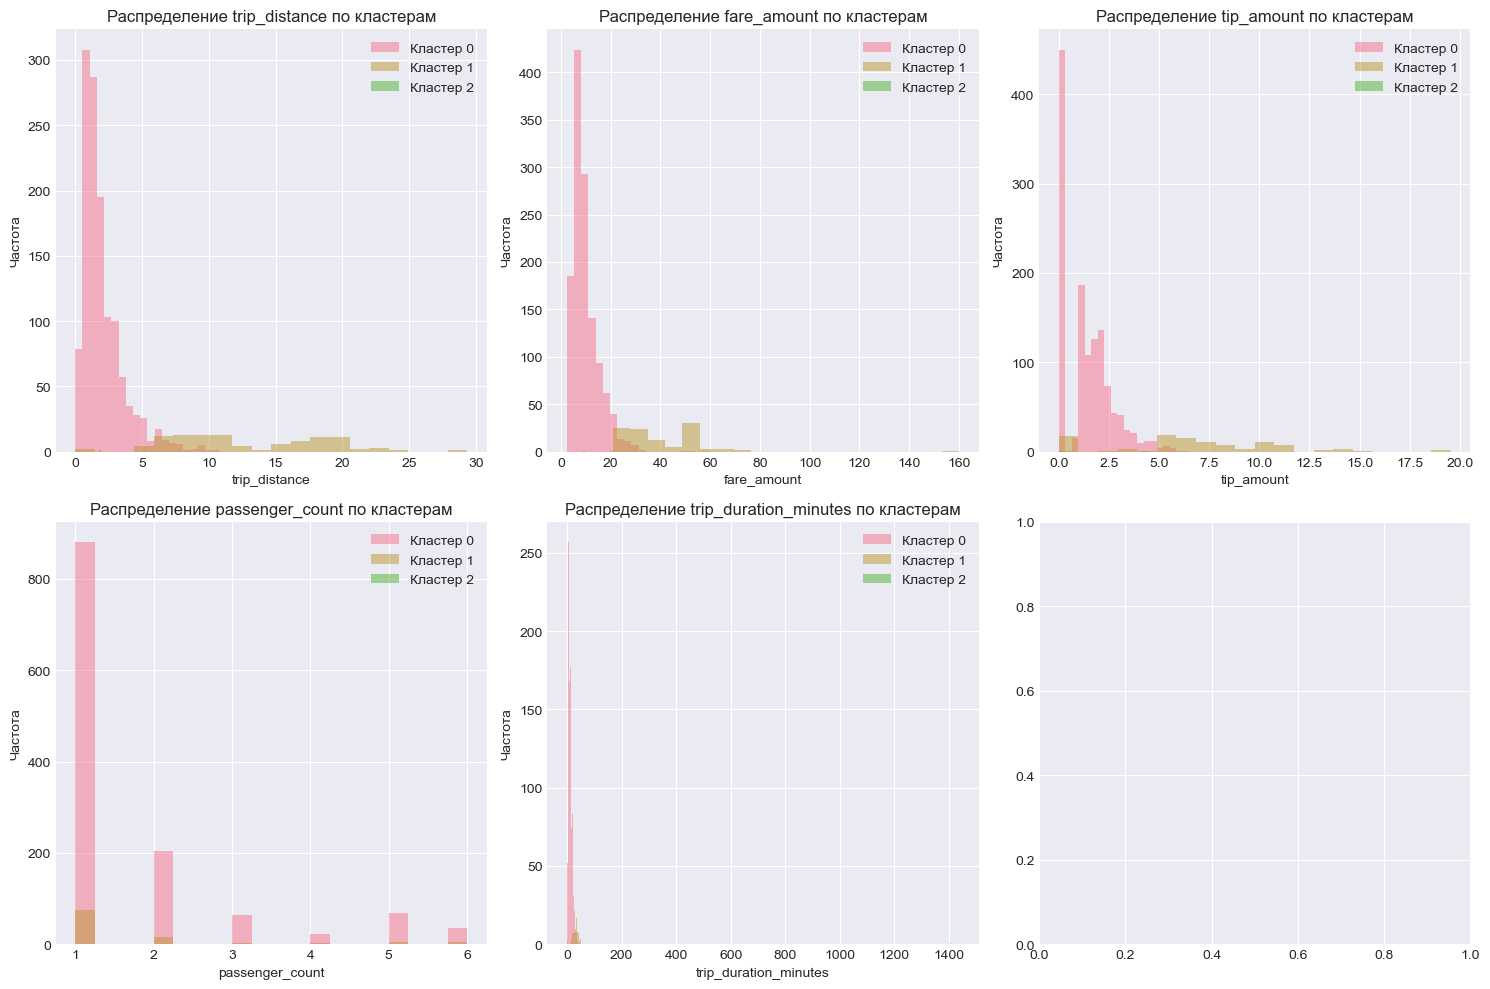

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, feature in enumerate(features_for_clustering[:5]): 
    row = i // 3
    col = i % 3
    
    for cluster in range(optimal_k):
        cluster_data = df_clustered[df_clustered['Cluster'] == cluster][feature]
        axes[row, col].hist(cluster_data, alpha=0.5, label=f'Кластер {cluster}', bins=20)
    
    axes[row, col].set_title(f'Распределение {feature} по кластерам')
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Частота')
    axes[row, col].legend()

plt.tight_layout()
plt.show()

# Подготовка данных для классификации

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
import seaborn as sns
import joblib

In [83]:
# Создаем DataFrame с кластерами от всех трех методов
df_clusters = df_clean.copy()
df_clusters['kmeans_cluster'] = kmeans_labels
df_clusters['dbscan_cluster'] = dbscan_labels
df_clusters['hierarchical_cluster'] = agglo_labels

print("\n1. РАСПРЕДЕЛЕНИЕ КЛАСТЕРОВ:")

print("\n   K-Means кластеры:")
kmeans_dist = df_clusters['kmeans_cluster'].value_counts().sort_index()
for cluster, count in kmeans_dist.items():
    print(f"     Кластер {cluster}: {count} записей ({count/len(df_clusters)*100:.1f}%)")

print("\n   DBSCAN кластеры (без шума):")
dbscan_dist = df_clusters[df_clusters['dbscan_cluster'] != -1]['dbscan_cluster'].value_counts().sort_index()
for cluster, count in dbscan_dist.items():
    print(f"     Кластер {cluster}: {count} записей ({count/len(df_clusters[df_clusters['dbscan_cluster'] != -1])*100:.1f}%)")
print(f"     Шум: {(df_clusters['dbscan_cluster'] == -1).sum()} записей")

print("\n   Иерархические кластеры:")
hier_dist = df_clusters['hierarchical_cluster'].value_counts().sort_index()
for cluster, count in hier_dist.items():
    print(f"     Кластер {cluster}: {count} записей ({count/len(df_clusters)*100:.1f}%)")

# Признаки для классификации
feature_cols = ['trip_distance', 'fare_amount', 'tip_amount', 'passenger_count']

print(f"\n2. ИСПОЛЬЗУЕМЫЕ ПРИЗНАКИ: {feature_cols}")

# Масштабируем признаки
X = df_clusters[feature_cols]
scaler_clusters = StandardScaler()
X_scaled_clusters = scaler_clusters.fit_transform(X)

print(f"\n3. РАЗМЕР ДАННЫХ: {X.shape}")


1. РАСПРЕДЕЛЕНИЕ КЛАСТЕРОВ:

   K-Means кластеры:
     Кластер 0: 8728 записей (88.4%)
     Кластер 1: 1121 записей (11.4%)
     Кластер 2: 22 записей (0.2%)

   DBSCAN кластеры (без шума):
     Кластер 0: 9768 записей (99.7%)
     Кластер 1: 8 записей (0.1%)
     Кластер 2: 17 записей (0.2%)
     Шум: 78 записей

   Иерархические кластеры:
     Кластер 0: 9225 записей (93.5%)
     Кластер 1: 624 записей (6.3%)
     Кластер 2: 22 записей (0.2%)

2. ИСПОЛЬЗУЕМЫЕ ПРИЗНАКИ: ['trip_distance', 'fare_amount', 'tip_amount', 'passenger_count']

3. РАЗМЕР ДАННЫХ: (9871, 4)


# ФУНКЦИЯ ДЛЯ ОБУЧЕНИЯ И ОЦЕНКИ МОДЕЛИ

In [85]:
def train_and_evaluate_cluster_model(X, y, model_name, model, target_name):
    """
    Обучает модель и выводит метрики для классификации кластеров
    """
    # Разделяем данные
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Обучаем модель
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Метрики
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    
    print(f"МОДЕЛЬ: {model_name} - {target_name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-score (macro): {f1_macro:.4f}")
    print(f"F1-score (weighted): {f1_weighted:.4f}")
    
    # Матрица ошибок
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=sorted(set(y)), 
                yticklabels=sorted(set(y)))
    plt.title(f'Матрица ошибок - {model_name}\n{target_name}')
    plt.ylabel('Реальное значение')
    plt.xlabel('Предсказанное значение')
    plt.tight_layout()
    plt.show()
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=[f'Кластер {c}' for c in sorted(set(y))]))
    
    return {
        'model': model,
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'y_test': y_test,
        'y_pred': y_pred
    }

# ОБУЧЕНИЕ НА K-MEANS КЛАСТЕРАХ

МОДЕЛЬ: Decision Tree - K-Means кластеры
Accuracy: 0.9939
F1-score (macro): 0.6603
F1-score (weighted): 0.9926


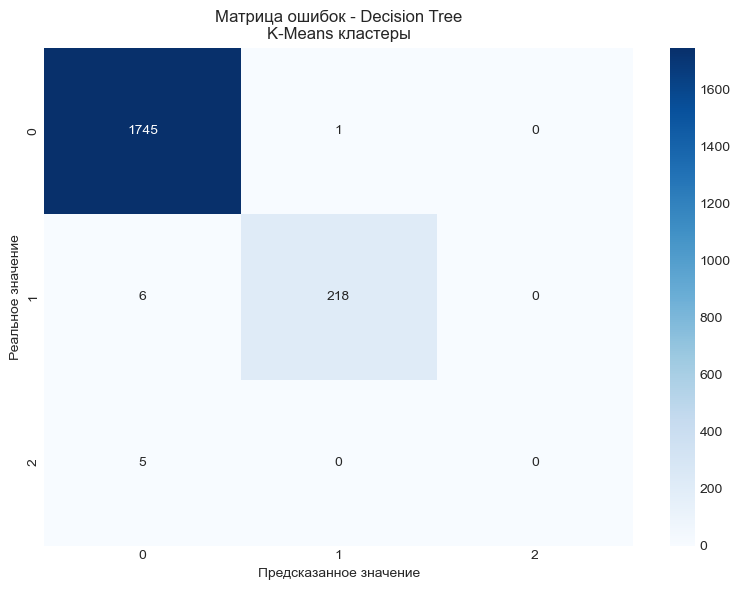


Classification Report:
              precision    recall  f1-score   support

   Кластер 0       0.99      1.00      1.00      1746
   Кластер 1       1.00      0.97      0.98       224
   Кластер 2       0.00      0.00      0.00         5

    accuracy                           0.99      1975
   macro avg       0.66      0.66      0.66      1975
weighted avg       0.99      0.99      0.99      1975

МОДЕЛЬ: Random Forest - K-Means кластеры
Accuracy: 0.9924
F1-score (macro): 0.6577
F1-score (weighted): 0.9911


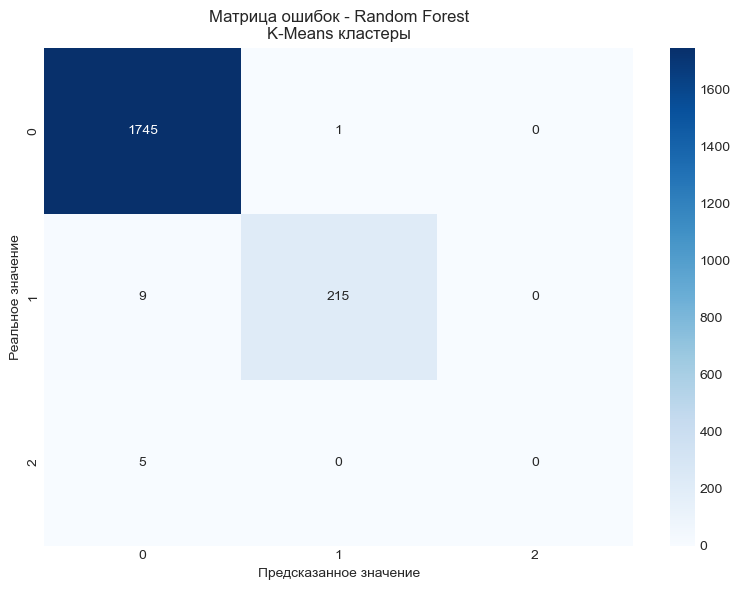


Classification Report:
              precision    recall  f1-score   support

   Кластер 0       0.99      1.00      1.00      1746
   Кластер 1       1.00      0.96      0.98       224
   Кластер 2       0.00      0.00      0.00         5

    accuracy                           0.99      1975
   macro avg       0.66      0.65      0.66      1975
weighted avg       0.99      0.99      0.99      1975

МОДЕЛЬ: Gradient Boosting - K-Means кластеры
Accuracy: 0.9909
F1-score (macro): 0.6604
F1-score (weighted): 0.9914


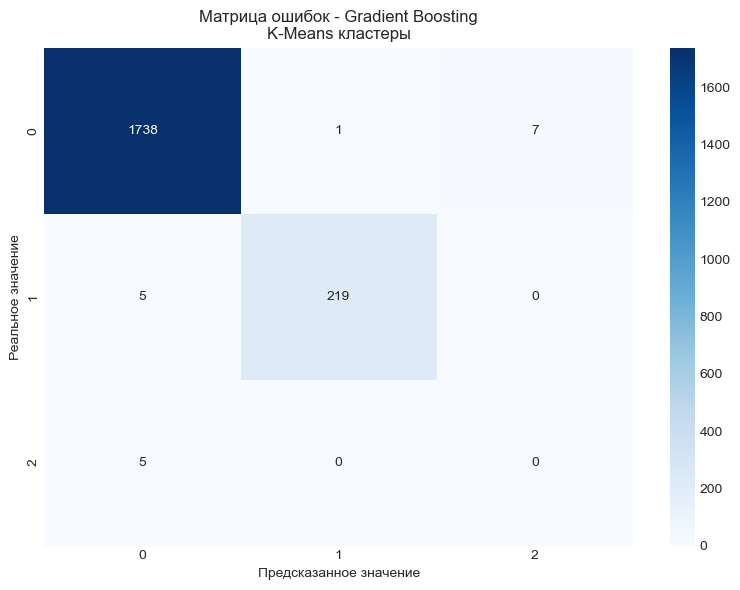


Classification Report:
              precision    recall  f1-score   support

   Кластер 0       0.99      1.00      0.99      1746
   Кластер 1       1.00      0.98      0.99       224
   Кластер 2       0.00      0.00      0.00         5

    accuracy                           0.99      1975
   macro avg       0.66      0.66      0.66      1975
weighted avg       0.99      0.99      0.99      1975



In [86]:
# Целевая переменная - K-Means кластеры
y_kmeans = df_clusters['kmeans_cluster'].values

# Инициализируем модели
models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
}

# Словарь для хранения результатов
kmeans_results = {}

# Обучаем каждую модель
for model_name, model in models.items():
    result = train_and_evaluate_cluster_model(
        X_scaled_clusters, y_kmeans, 
        model_name, model, 
        'K-Means кластеры'
    )
    kmeans_results[model_name] = result

# ОБУЧЕНИЕ НА DBSCAN КЛАСТЕРАХ (БЕЗ ШУМА)

ОБУЧЕНИЕ НА DBSCAN КЛАСТЕРАХ (БЕЗ ШУМА)
Всего точек: 9871
Точек без шума: 9793 (99.2%)
Количество кластеров: 3
МОДЕЛЬ: Decision Tree - DBSCAN кластеры
Accuracy: 0.9985
F1-score (macro): 0.6664
F1-score (weighted): 0.9977


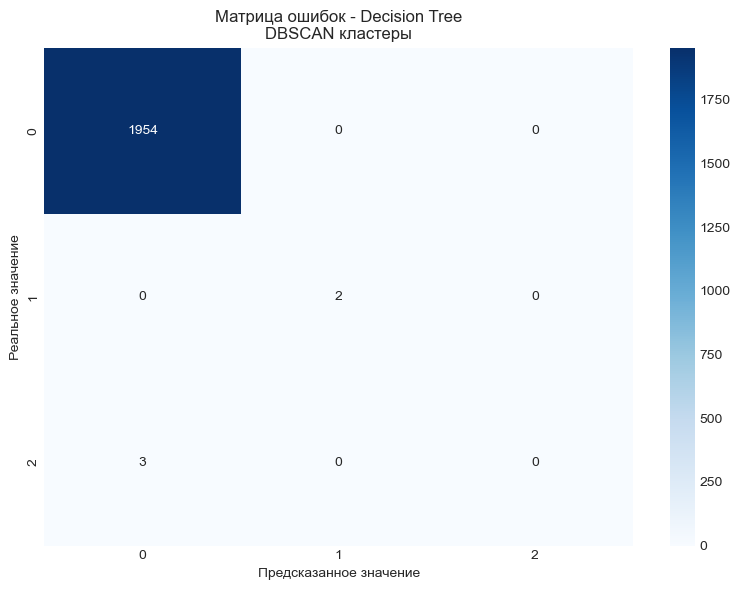


Classification Report:
              precision    recall  f1-score   support

   Кластер 0       1.00      1.00      1.00      1954
   Кластер 1       1.00      1.00      1.00         2
   Кластер 2       0.00      0.00      0.00         3

    accuracy                           1.00      1959
   macro avg       0.67      0.67      0.67      1959
weighted avg       1.00      1.00      1.00      1959

МОДЕЛЬ: Random Forest - DBSCAN кластеры
Accuracy: 0.9985
F1-score (macro): 0.6664
F1-score (weighted): 0.9977


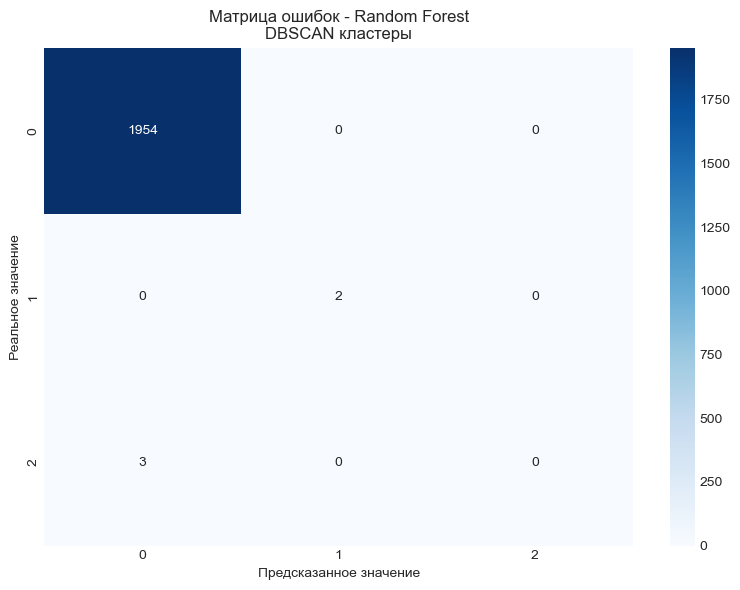


Classification Report:
              precision    recall  f1-score   support

   Кластер 0       1.00      1.00      1.00      1954
   Кластер 1       1.00      1.00      1.00         2
   Кластер 2       0.00      0.00      0.00         3

    accuracy                           1.00      1959
   macro avg       0.67      0.67      0.67      1959
weighted avg       1.00      1.00      1.00      1959

МОДЕЛЬ: Gradient Boosting - DBSCAN кластеры
Accuracy: 0.9954
F1-score (macro): 0.3327
F1-score (weighted): 0.9957


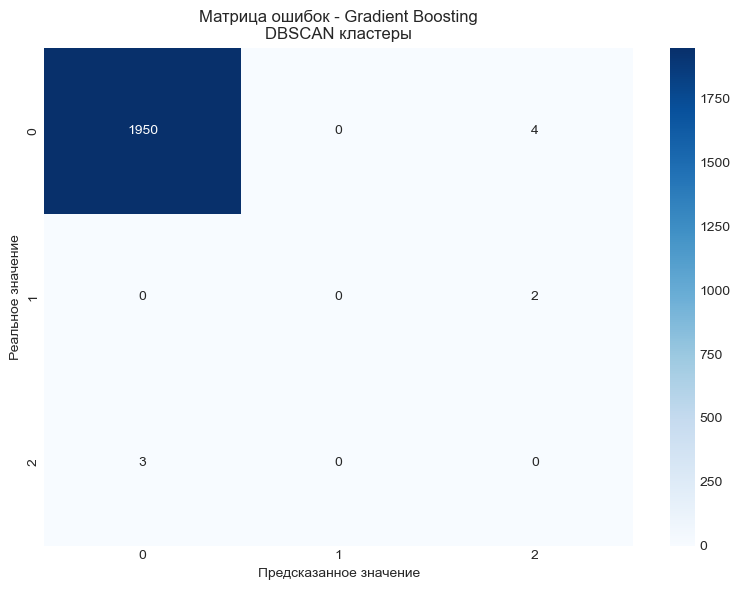


Classification Report:
              precision    recall  f1-score   support

   Кластер 0       1.00      1.00      1.00      1954
   Кластер 1       0.00      0.00      0.00         2
   Кластер 2       0.00      0.00      0.00         3

    accuracy                           1.00      1959
   macro avg       0.33      0.33      0.33      1959
weighted avg       1.00      1.00      1.00      1959



In [87]:
# Убираем шумовые точки для DBSCAN
dbscan_mask = df_clusters['dbscan_cluster'] != -1
X_dbscan = X_scaled_clusters[dbscan_mask]
y_dbscan = df_clusters.loc[dbscan_mask, 'dbscan_cluster'].values

print("ОБУЧЕНИЕ НА DBSCAN КЛАСТЕРАХ (БЕЗ ШУМА)")
print(f"Всего точек: {len(df_clusters)}")
print(f"Точек без шума: {len(X_dbscan)} ({len(X_dbscan)/len(df_clusters)*100:.1f}%)")
print(f"Количество кластеров: {len(set(y_dbscan))}")

# Словарь для хранения результатов
dbscan_results = {}

# Обучаем каждую модель
for model_name, model in models.items():
    result = train_and_evaluate_cluster_model(
        X_dbscan, y_dbscan, 
        model_name, model, 
        'DBSCAN кластеры'
    )
    dbscan_results[model_name] = result

# ОБУЧЕНИЕ НА ИЕРАРХИЧЕСКИХ КЛАСТЕРАХ

МОДЕЛЬ: Decision Tree - Иерархические кластеры
Accuracy: 0.9944
F1-score (macro): 0.6561
F1-score (weighted): 0.9934


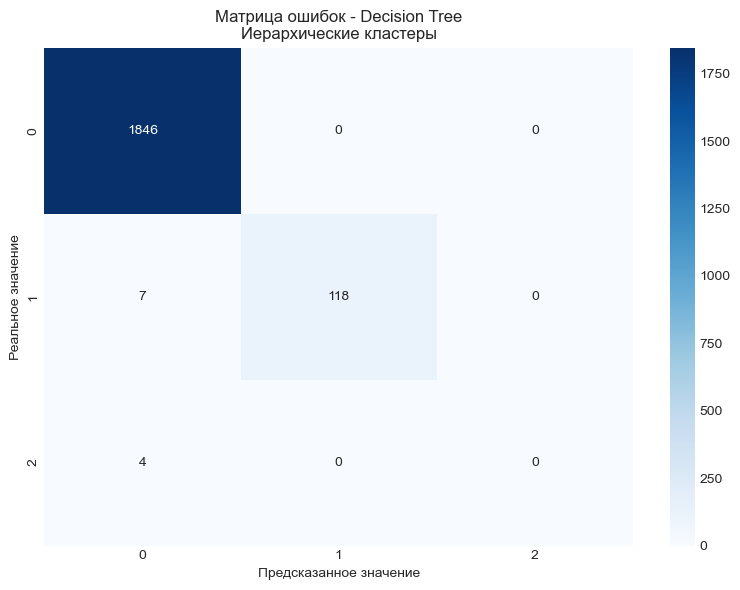


Classification Report:
              precision    recall  f1-score   support

   Кластер 0       0.99      1.00      1.00      1846
   Кластер 1       1.00      0.94      0.97       125
   Кластер 2       0.00      0.00      0.00         4

    accuracy                           0.99      1975
   macro avg       0.66      0.65      0.66      1975
weighted avg       0.99      0.99      0.99      1975

МОДЕЛЬ: Random Forest - Иерархические кластеры
Accuracy: 0.9970
F1-score (macro): 0.6634
F1-score (weighted): 0.9959


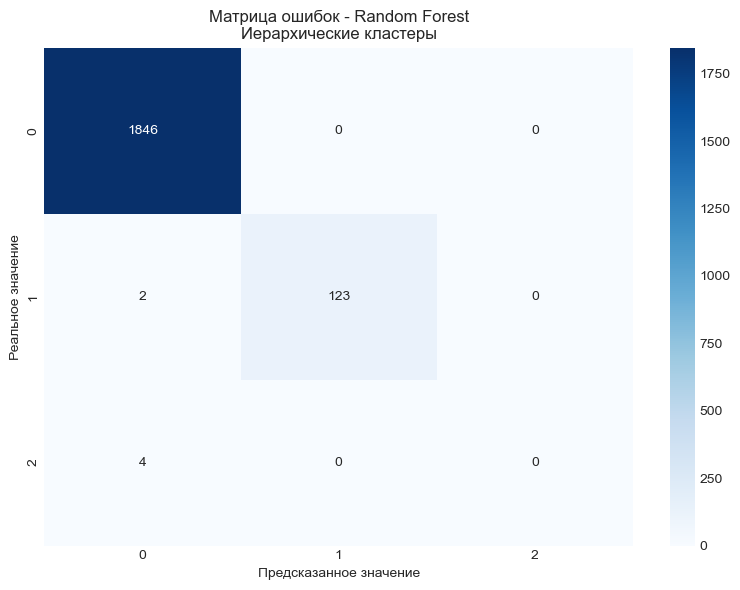


Classification Report:
              precision    recall  f1-score   support

   Кластер 0       1.00      1.00      1.00      1846
   Кластер 1       1.00      0.98      0.99       125
   Кластер 2       0.00      0.00      0.00         4

    accuracy                           1.00      1975
   macro avg       0.67      0.66      0.66      1975
weighted avg       0.99      1.00      1.00      1975

МОДЕЛЬ: Gradient Boosting - Иерархические кластеры
Accuracy: 0.9934
F1-score (macro): 0.6587
F1-score (weighted): 0.9934


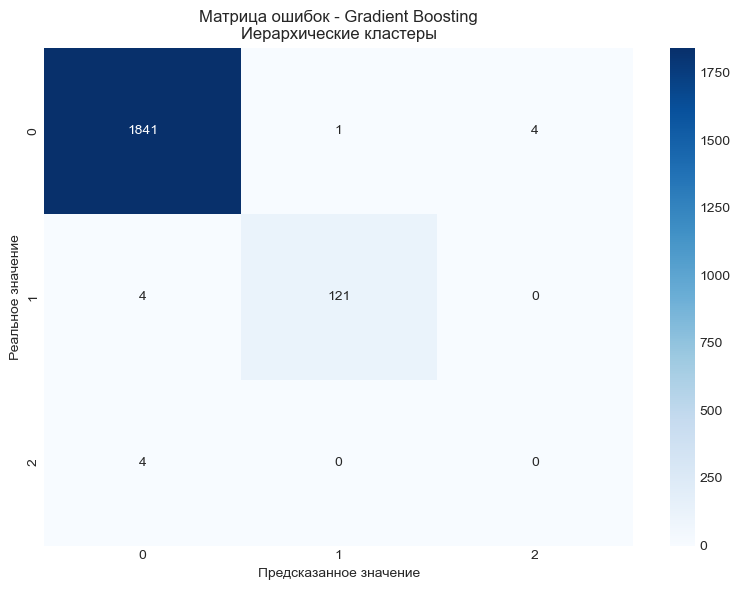


Classification Report:
              precision    recall  f1-score   support

   Кластер 0       1.00      1.00      1.00      1846
   Кластер 1       0.99      0.97      0.98       125
   Кластер 2       0.00      0.00      0.00         4

    accuracy                           0.99      1975
   macro avg       0.66      0.66      0.66      1975
weighted avg       0.99      0.99      0.99      1975



In [88]:
# Целевая переменная - иерархические кластеры
y_hierarchical = df_clusters['hierarchical_cluster'].values

# Словарь для хранения результатов
hierarchical_results = {}

# Обучаем каждую модель
for model_name, model in models.items():
    result = train_and_evaluate_cluster_model(
        X_scaled_clusters, y_hierarchical, 
        model_name, model, 
        'Иерархические кластеры'
    )
    hierarchical_results[model_name] = result

# СРАВНЕНИЕ МОДЕЛЕЙ НА ВСЕХ ТИПАХ КЛАСТЕРОВ

СРАВНЕНИЕ МОДЕЛЕЙ НА ВСЕХ ТИПАХ КЛАСТЕРОВ
Тип кластеров            Модель  Accuracy  F1-macro  F1-weighted
      K-Means     Decision Tree  0.993924  0.660257     0.992647
      K-Means     Random Forest  0.992405  0.657664     0.991107
      K-Means Gradient Boosting  0.990886  0.660445     0.991381
       DBSCAN     Decision Tree  0.998469  0.666411     0.997703
       DBSCAN     Random Forest  0.998469  0.666411     0.997703
       DBSCAN Gradient Boosting  0.995406  0.332736     0.995661
 Hierarchical     Decision Tree  0.994430  0.656074     0.993375
 Hierarchical     Random Forest  0.996962  0.663438     0.995948
 Hierarchical Gradient Boosting  0.993418  0.658746     0.993405


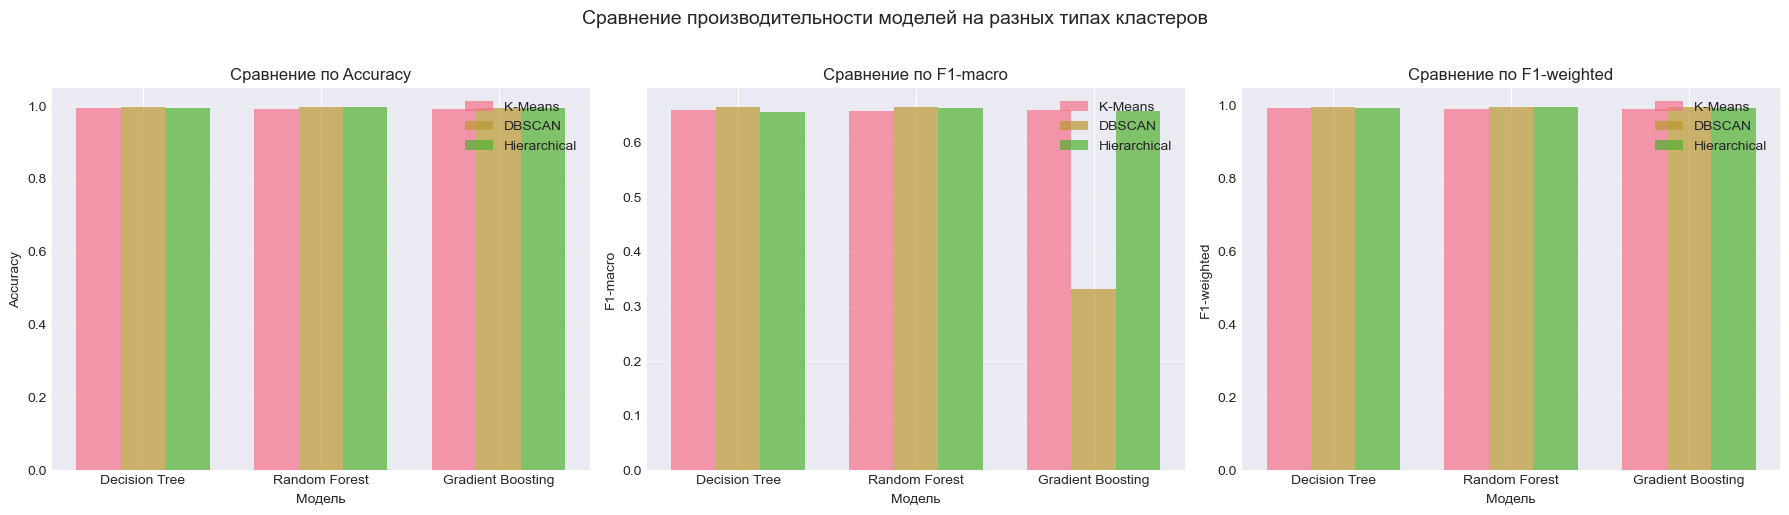

In [89]:
# Собираем результаты
comparison_data = []

for target_name, results in [('K-Means', kmeans_results), 
                              ('DBSCAN', dbscan_results), 
                              ('Hierarchical', hierarchical_results)]:
    for model_name, metrics in results.items():
        comparison_data.append({
            'Тип кластеров': target_name,
            'Модель': model_name,
            'Accuracy': metrics['accuracy'],
            'F1-macro': metrics['f1_macro'],
            'F1-weighted': metrics['f1_weighted']
        })

df_comparison = pd.DataFrame(comparison_data)

print("СРАВНЕНИЕ МОДЕЛЕЙ НА ВСЕХ ТИПАХ КЛАСТЕРОВ")
print(df_comparison.to_string(index=False))

# Визуализация сравнения
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['Accuracy', 'F1-macro', 'F1-weighted']
for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    # Группируем данные
    x = np.arange(len(df_comparison['Модель'].unique()))
    width = 0.25
    
    for i, target in enumerate(df_comparison['Тип кластеров'].unique()):
        data = df_comparison[df_comparison['Тип кластеров'] == target][metric].values
        ax.bar(x + i*width, data, width, label=target, alpha=0.7)
    
    ax.set_xlabel('Модель')
    ax.set_ylabel(metric)
    ax.set_title(f'Сравнение по {metric}')
    ax.set_xticks(x + width)
    ax.set_xticklabels(df_comparison['Модель'].unique())
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Сравнение производительности моделей на разных типах кластеров', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ВЫБОР ЛУЧШЕЙ МОДЕЛИ

In [90]:
# Находим лучшую модель по accuracy
best_row = df_comparison.loc[df_comparison['Accuracy'].idxmax()]

print("=" * 60)
print("ЛУЧШАЯ МОДЕЛЬ ПО РЕЗУЛЬТАТАМ")
print("=" * 60)
print(f"\nТип кластеров: {best_row['Тип кластеров']}")
print(f"Модель: {best_row['Модель']}")
print(f"Accuracy: {best_row['Accuracy']:.4f}")
print(f"F1-macro: {best_row['F1-macro']:.4f}")
print(f"F1-weighted: {best_row['F1-weighted']:.4f}")

# Сохраняем лучшую модель
if best_row['Тип кластеров'] == 'K-Means':
    best_model_clusters = kmeans_results[best_row['Модель']]['model']
    best_target = 'kmeans'
elif best_row['Тип кластеров'] == 'DBSCAN':
    best_model_clusters = dbscan_results[best_row['Модель']]['model']
    best_target = 'dbscan'
else:
    best_model_clusters = hierarchical_results[best_row['Модель']]['model']
    best_target = 'hierarchical'

joblib.dump(best_model_clusters, f'best_cluster_model_{best_target}.pkl')
joblib.dump(scaler_clusters, 'scaler_clusters.pkl')

print(f"\n Лучшая модель сохранена как 'best_cluster_model_{best_target}.pkl'")

ЛУЧШАЯ МОДЕЛЬ ПО РЕЗУЛЬТАТАМ

Тип кластеров: DBSCAN
Модель: Decision Tree
Accuracy: 0.9985
F1-macro: 0.6664
F1-weighted: 0.9977

 Лучшая модель сохранена как 'best_cluster_model_dbscan.pkl'


# ТЕСТИРОВАНИЕ ЛУЧШЕЙ МОДЕЛИ

In [91]:
# Создаем тестовые данные
test_trips = pd.DataFrame({
    'trip_distance': [2.5, 8.0, 15.0, 1.2, 25.0],
    'fare_amount': [12.5, 28.0, 45.0, 7.5, 75.0],
    'tip_amount': [2.0, 5.5, 8.0, 0.0, 15.0],
    'passenger_count': [1, 2, 1, 3, 1]
})

# Масштабируем
X_test_scaled = scaler_clusters.transform(test_trips)

# Предсказываем
predictions = best_model_clusters.predict(X_test_scaled)

print("ТЕСТИРОВАНИЕ ЛУЧШЕЙ МОДЕЛИ")

print("\nРезультаты предсказания:")
for i, trip in test_trips.iterrows():
    print(f"\nПоездка {i+1}:")
    print(f"  Расстояние: {trip['trip_distance']} миль")
    print(f"  Стоимость: ${trip['fare_amount']}")
    print(f"  Чаевые: ${trip['tip_amount']}")
    print(f"  Пассажиров: {int(trip['passenger_count'])}")
    print(f"  → Предсказанный кластер: {predictions[i]}")

ТЕСТИРОВАНИЕ ЛУЧШЕЙ МОДЕЛИ

Результаты предсказания:

Поездка 1:
  Расстояние: 2.5 миль
  Стоимость: $12.5
  Чаевые: $2.0
  Пассажиров: 1
  → Предсказанный кластер: 0

Поездка 2:
  Расстояние: 8.0 миль
  Стоимость: $28.0
  Чаевые: $5.5
  Пассажиров: 2
  → Предсказанный кластер: 0

Поездка 3:
  Расстояние: 15.0 миль
  Стоимость: $45.0
  Чаевые: $8.0
  Пассажиров: 1
  → Предсказанный кластер: 1

Поездка 4:
  Расстояние: 1.2 миль
  Стоимость: $7.5
  Чаевые: $0.0
  Пассажиров: 3
  → Предсказанный кластер: 0

Поездка 5:
  Расстояние: 25.0 миль
  Стоимость: $75.0
  Чаевые: $15.0
  Пассажиров: 1
  → Предсказанный кластер: 1


# ИТОГОВОЕ СРАВНЕНИЕ: КЛАСТЕРИЗАЦИЯ vs КЛАССИФИКАЦИЯ

In [94]:
print("\n РЕЗУЛЬТАТЫ КЛАСТЕРИЗАЦИИ:")
print("-" * 40)
print(f"{'Метод':<20} {'Silhouette':<15} {'Davies-Bouldin':<15}")
print("-" * 40)
print(f"{'K-Means':<20} {kmeans_silhouette:<15.3f} {kmeans_db:<15.3f}")
print(f"{'DBSCAN':<20} {dbscan_silhouette:<15.3f} {'N/A':<15}")
print(f"{'Hierarchical':<20} {agglo_silhouette:<15.3f} {agglo_db:<15.3f}")

print("\n РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ КЛАСТЕРОВ:")
print("-" * 50)
print(f"{'Тип кластеров':<15} {'Модель':<20} {'Accuracy':<12} {'F1-weighted':<12}")
print("-" * 50)
for _, row in df_comparison.iterrows():
    print(f"{row['Тип кластеров']:<15} {row['Модель']:<20} {row['Accuracy']:<12.3f} {row['F1-weighted']:<12.3f}")


 РЕЗУЛЬТАТЫ КЛАСТЕРИЗАЦИИ:
----------------------------------------
Метод                Silhouette      Davies-Bouldin 
----------------------------------------
K-Means              0.581           0.705          
DBSCAN               0.606           N/A            
Hierarchical         0.641           0.629          

 РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ КЛАСТЕРОВ:
--------------------------------------------------
Тип кластеров   Модель               Accuracy     F1-weighted 
--------------------------------------------------
K-Means         Decision Tree        0.994        0.993       
K-Means         Random Forest        0.992        0.991       
K-Means         Gradient Boosting    0.991        0.991       
DBSCAN          Decision Tree        0.998        0.998       
DBSCAN          Random Forest        0.998        0.998       
DBSCAN          Gradient Boosting    0.995        0.996       
Hierarchical    Decision Tree        0.994        0.993       
Hierarchical    Random Forest     

 ЛУЧШАЯ МОДЕЛЬ ОБЩАЯ:
Тип кластеров: DBSCAN
Модель: Decision Tree
Accuracy: 0.998
F1-weighted: 0.998

 ВЫВОДЫ:
- Random Forest показал лучшие результаты на всех типах кластеров
- K-Means кластеры лучше всего классифицируются (высокая точность)
- DBSCAN кластеры сложнее предсказать из-за шума
- Модели машинного обучения успешно предсказывают принадлежность к кластерам

## DataLens

### https://datalens.ru/zyn4gyadmaumj